# Real-time Credit Card Fraud Detection System
## End-to-end ML Pipeline dengan LightGBM, SHAP, dan Business Impact Analysis

**Author:** Nadine Riskia Windi Paramita
**Dataset:** Kaggle Credit Card Fraud Detection (ULB)  
**Objective:** Membangun sistem deteksi penipuan yang production-ready dengan
penanganan imbalanced data, explainability, dan evaluasi berbasis dampak bisnis.

---
## FASE 1: Setup & Data Understanding
---


### 1.1 Setup & Import


In [1]:
# ============================================================
# Install & Import Libraries
# ============================================================

!pip install lightgbm shap imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ML - Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ML - Models
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest, RandomForestClassifier

# Imbalanced handling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    f1_score, precision_score, recall_score
)

# Explainability
import shap

# Utilities
import warnings
warnings.filterwarnings('ignore')
import time

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
RANDOM_STATE = 42

print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


### 1.2 Load Data & First Look

In [2]:
# ============================================================
# Mount Drive & Load Data
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# Sesuaikan path dengan lokasi file kamu di Drive
DATA_PATH = '/content/drive/MyDrive/credit-card-fraud/creditcard.csv'

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Mounted at /content/drive
Dataset shape: (284807, 31)
Memory usage: 67.36 MB


In [3]:
# ============================================================
# Initial Data Inspection
# ============================================================

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print("\n📋 Columns:")
print(df.columns.tolist())

print("\n📊 Data Types & Non-null Counts:")
print(df.info())

print("\n📈 Basic Statistics:")
df.describe()

DATASET OVERVIEW

📋 Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

📊 Data Types & Non-null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14 

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


CLASS DISTRIBUTION

🟢 Normal Transactions : 284,315 (99.8273%)
🔴 Fraud  Transactions : 492 (0.1727%)

⚠️  Imbalance Ratio    : 1 fraud per 577 normal transactions


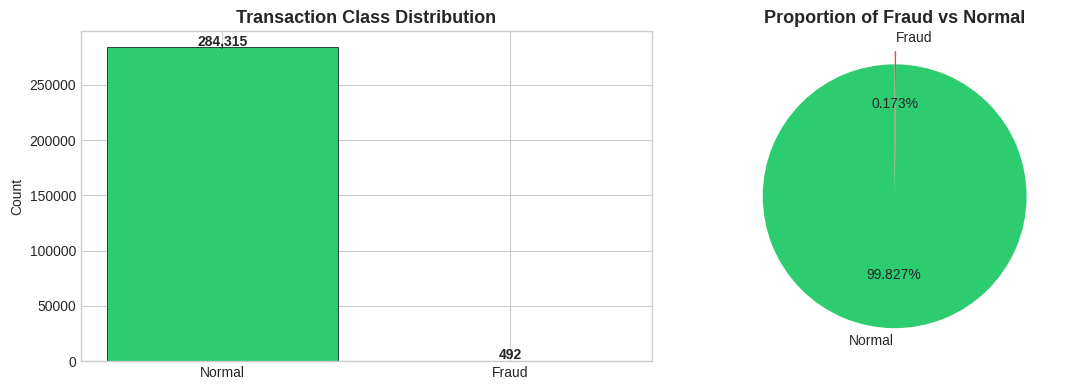


💡 Key Insight: Dataset ini sangat imbalanced (0.172% fraud).
   Ini berarti accuracy BUKAN metrik yang tepat.
   Kita akan fokus pada PR-AUC dan Recall.


In [4]:
# ============================================================
# Understanding the Data Structure
# ============================================================

# Cek class distribution
fraud_count = df['Class'].value_counts()
fraud_pct = df['Class'].value_counts(normalize=True) * 100

print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)
print(f"\n🟢 Normal Transactions : {fraud_count[0]:,} ({fraud_pct[0]:.4f}%)")
print(f"🔴 Fraud  Transactions : {fraud_count[1]:,} ({fraud_pct[1]:.4f}%)")
print(f"\n⚠️  Imbalance Ratio    : 1 fraud per {fraud_count[0]//fraud_count[1]:.0f} normal transactions")

# Visualisasi distribusi kelas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Normal', 'Fraud'], fraud_count.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5)
axes[0].set_title('Transaction Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_count.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(fraud_count.values, labels=['Normal', 'Fraud'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.3f%%',
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Proportion of Fraud vs Normal', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Key Insight: Dataset ini sangat imbalanced (0.172% fraud).")
print("   Ini berarti accuracy BUKAN metrik yang tepat.")
print("   Kita akan fokus pada PR-AUC dan Recall.")

### 1.3 Memahami Fitur Dataset

In [5]:
# ============================================================
# Feature Understanding
# ============================================================

feature_info = """
PENJELASAN FITUR DATASET
========================

📌 V1 - V28  : Hasil PCA transformation dari fitur asli transaksi.
               Fitur asli DIRAHASIAKAN oleh penerbit dataset karena
               alasan privasi nasabah. Ini umum terjadi di industri keuangan.

📌 Time      : Detik yang berlalu sejak transaksi pertama dalam dataset.
               Bukan timestamp absolut — kita perlu feature engineering.

📌 Amount    : Nominal transaksi dalam Euro. BELUM di-scale.
               Ini satu-satunya fitur yang kita tahu nilainya secara nyata.

📌 Class     : Target variable.
               0 = Transaksi Normal
               1 = Penipuan (Fraud)

⚠️  Catatan Penting :
    Karena V1-V28 sudah PCA, kita tidak bisa melakukan domain-specific
    feature engineering pada fitur tersebut. Yang bisa kita engineer
    adalah fitur Time dan Amount.
"""
print(feature_info)

# Cek missing values
print("Missing Values per Column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "✅ Tidak ada missing values")


PENJELASAN FITUR DATASET

📌 V1 - V28  : Hasil PCA transformation dari fitur asli transaksi.
               Fitur asli DIRAHASIAKAN oleh penerbit dataset karena
               alasan privasi nasabah. Ini umum terjadi di industri keuangan.

📌 Time      : Detik yang berlalu sejak transaksi pertama dalam dataset.
               Bukan timestamp absolut — kita perlu feature engineering.

📌 Amount    : Nominal transaksi dalam Euro. BELUM di-scale.
               Ini satu-satunya fitur yang kita tahu nilainya secara nyata.

📌 Class     : Target variable.
               0 = Transaksi Normal
               1 = Penipuan (Fraud)

⚠️  Catatan Penting :
    Karena V1-V28 sudah PCA, kita tidak bisa melakukan domain-specific
    feature engineering pada fitur tersebut. Yang bisa kita engineer
    adalah fitur Time dan Amount.

Missing Values per Column:
✅ Tidak ada missing values


## FASE 2: Exploratory Data Analysis (EDA)
---

2.1 Analisis Fitur Amount

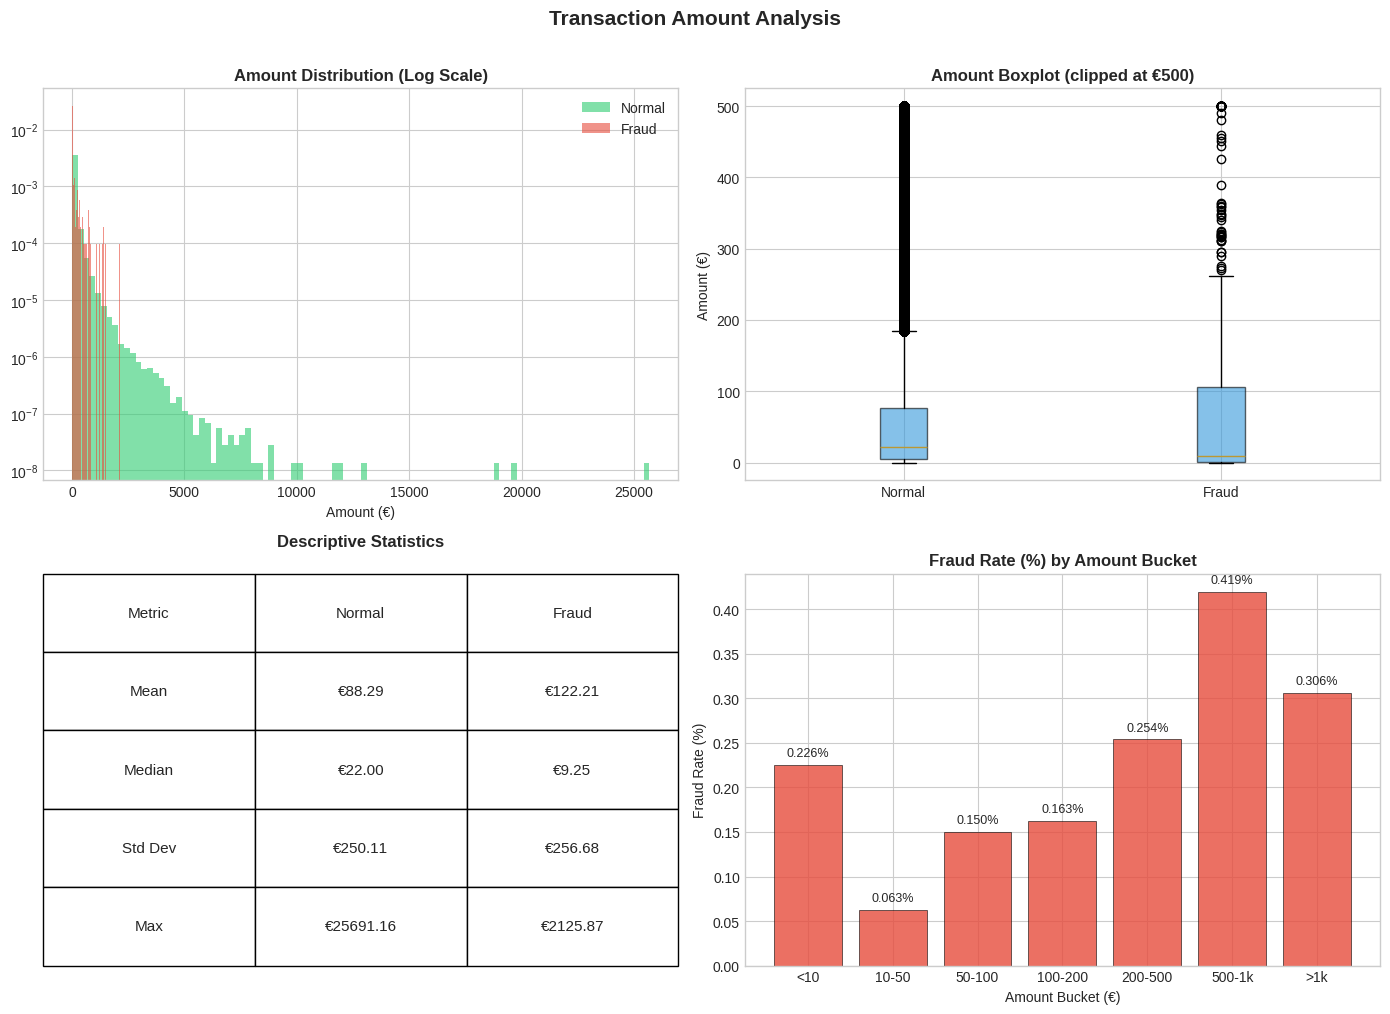

💡 KEY INSIGHTS - Amount
Mean fraud amount   : €122.21
Mean normal amount  : €88.29
Std dev fraud amount  : €256.68
Std dev normal amount : €250.11
Median fraud amount   : €9.25

→ Fraud cenderung pada transaksi nominal KECIL (median lebih rendah).
→ TAPI std dev fraud justru LEBIH TINGGI — distribusi lebih lebar.
→ Fraudster beroperasi di dua ujung: nominal sangat kecil (card testing)
   DAN nominal sangat besar (cash out setelah kartu berhasil dibobol).
→ Implikasi: Amount SAJA tidak cukup — butuh kombinasi fitur kontekstual.


In [6]:
# ============================================================
# Amount Distribution Analysis
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Transaction Amount Analysis', fontsize=15, fontweight='bold', y=1.01)

fraud_df   = df[df['Class'] == 1]
normal_df  = df[df['Class'] == 0]

# --- Plot 1: Raw distribution (log scale) ---
axes[0, 0].hist(normal_df['Amount'], bins=100, alpha=0.6,
                color='#2ecc71', label='Normal', density=True)
axes[0, 0].hist(fraud_df['Amount'], bins=100, alpha=0.6,
                color='#e74c3c', label='Fraud', density=True)
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Amount Distribution (Log Scale)', fontweight='bold')
axes[0, 0].set_xlabel('Amount (€)')
axes[0, 0].legend()

# --- Plot 2: Boxplot perbandingan ---
axes[0, 1].boxplot(
    [normal_df['Amount'].clip(upper=500),
     fraud_df['Amount'].clip(upper=500)],
    labels=['Normal', 'Fraud'],
    patch_artist=True,
    boxprops=dict(facecolor='#3498db', alpha=0.6)
)
axes[0, 1].set_title('Amount Boxplot (clipped at €500)', fontweight='bold')
axes[0, 1].set_ylabel('Amount (€)')

# --- Plot 3: Statistik komparatif ---
stats_data = {
    'Metric': ['Mean', 'Median', 'Std Dev', 'Max'],
    'Normal': [
        f"€{normal_df['Amount'].mean():.2f}",
        f"€{normal_df['Amount'].median():.2f}",
        f"€{normal_df['Amount'].std():.2f}",
        f"€{normal_df['Amount'].max():.2f}"
    ],
    'Fraud': [
        f"€{fraud_df['Amount'].mean():.2f}",
        f"€{fraud_df['Amount'].median():.2f}",
        f"€{fraud_df['Amount'].std():.2f}",
        f"€{fraud_df['Amount'].max():.2f}"
    ]
}

stats_df_display = pd.DataFrame(stats_data)
axes[1, 0].axis('off')
table = axes[1, 0].table(
    cellText=stats_df_display.values,
    colLabels=stats_df_display.columns,
    cellLoc='center', loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
axes[1, 0].set_title('Descriptive Statistics', fontweight='bold', pad=20)

# --- Plot 4: Fraud rate per amount bucket ---
df['amount_bucket'] = pd.cut(df['Amount'],
    bins=[0, 10, 50, 100, 200, 500, 1000, df['Amount'].max()],
    labels=['<10', '10-50', '50-100', '100-200', '200-500', '500-1k', '>1k'])

fraud_rate_by_amount = df.groupby('amount_bucket', observed=True)['Class'].mean() * 100

axes[1, 1].bar(fraud_rate_by_amount.index, fraud_rate_by_amount.values,
               color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.5)
axes[1, 1].set_title('Fraud Rate (%) by Amount Bucket', fontweight='bold')
axes[1, 1].set_xlabel('Amount Bucket (€)')
axes[1, 1].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(fraud_rate_by_amount.values):
    axes[1, 1].text(i, v + 0.01, f'{v:.3f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('amount_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key insights
print("=" * 60)
print("💡 KEY INSIGHTS - Amount")
print("=" * 60)
print(f"Mean fraud amount   : €{fraud_df['Amount'].mean():.2f}")
print(f"Mean normal amount  : €{normal_df['Amount'].mean():.2f}")

# ↓ TAMBAHKAN 3 BARIS INI
print(f"Std dev fraud amount  : €{fraud_df['Amount'].std():.2f}")
print(f"Std dev normal amount : €{normal_df['Amount'].std():.2f}")
print(f"Median fraud amount   : €{fraud_df['Amount'].median():.2f}")

print(f"\n→ Fraud cenderung pada transaksi nominal KECIL (median lebih rendah).")
print(f"→ TAPI std dev fraud justru LEBIH TINGGI — distribusi lebih lebar.")
print(f"→ Fraudster beroperasi di dua ujung: nominal sangat kecil (card testing)")
print(f"   DAN nominal sangat besar (cash out setelah kartu berhasil dibobol).")
print(f"→ Implikasi: Amount SAJA tidak cukup — butuh kombinasi fitur kontekstual.")

### 2.2 Analisis Fitur 'Time' (Temporal Analysis)

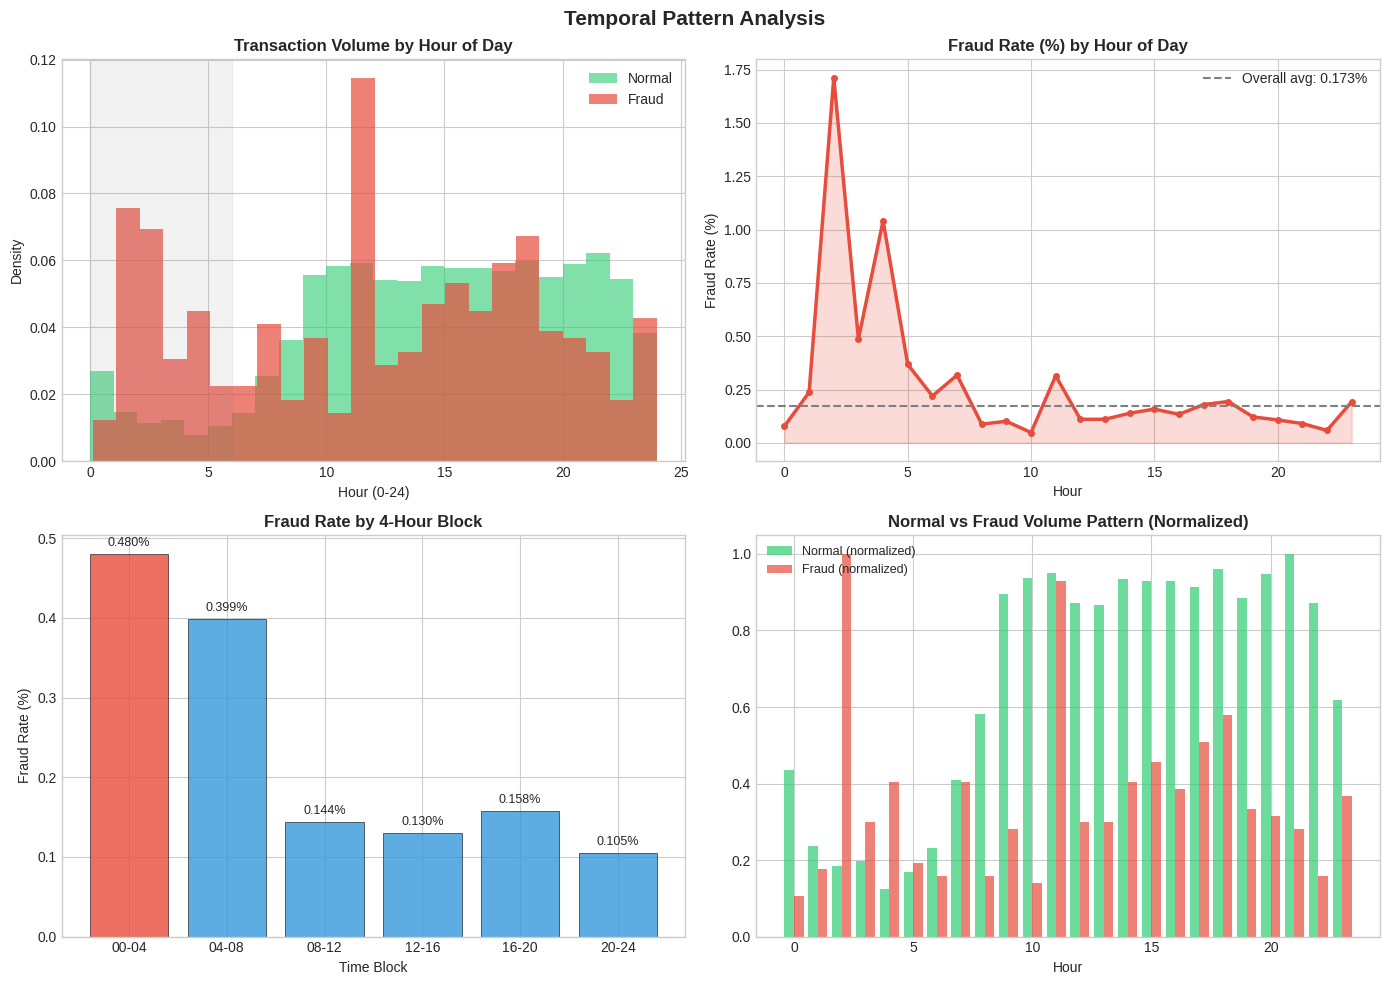

Peak fraud hour : 2:00
Peak fraud rate : 1.713%

→ Fraud lebih sering terjadi di jam sepi (dini hari)
→ Fitur 'hour_of_day' akan kita gunakan di feature engineering


In [7]:
# ============================================================
# Temporal Pattern Analysis
# ============================================================

# Konversi Time ke jam
df['hour_of_day'] = (df['Time'] / 3600) % 24
df['hour_bin'] = df['hour_of_day'].astype(int)

# Re-define setelah hour_of_day & hour_bin ditambahkan ke df
fraud_df  = df[df['Class'] == 1]
normal_df = df[df['Class'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Temporal Pattern Analysis', fontsize=15, fontweight='bold')

# --- Plot 1: Volume transaksi per jam ---
axes[0, 0].hist(normal_df['hour_of_day'], bins=24, alpha=0.6,
                color='#2ecc71', label='Normal', density=True)
axes[0, 0].hist(fraud_df['hour_of_day'], bins=24, alpha=0.7,
                color='#e74c3c', label='Fraud', density=True)
axes[0, 0].set_title('Transaction Volume by Hour of Day', fontweight='bold')
axes[0, 0].set_xlabel('Hour (0-24)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()
axes[0, 0].axvspan(0, 6, alpha=0.1, color='gray')

# --- Plot 2: Fraud rate per jam ---
fraud_rate_hourly = df.groupby('hour_bin')['Class'].mean() * 100

axes[0, 1].plot(fraud_rate_hourly.index, fraud_rate_hourly.values,
                color='#e74c3c', linewidth=2.5, marker='o', markersize=4)
axes[0, 1].fill_between(fraud_rate_hourly.index, fraud_rate_hourly.values,
                         alpha=0.2, color='#e74c3c')
axes[0, 1].set_title('Fraud Rate (%) by Hour of Day', fontweight='bold')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Fraud Rate (%)')
axes[0, 1].axhline(y=df['Class'].mean() * 100, color='gray',
                    linestyle='--', label=f'Overall avg: {df["Class"].mean()*100:.3f}%')
axes[0, 1].legend()

# --- Plot 3: Fraud rate per 4-hour block ---
df['time_block'] = pd.cut(df['hour_of_day'],
    bins=[0, 4, 8, 12, 16, 20, 24],
    labels=['00-04', '04-08', '08-12', '12-16', '16-20', '20-24'],
    include_lowest=True)

time_stats = df.groupby('time_block', observed=True).agg(
    total=('Class', 'count'),
    fraud=('Class', 'sum')
).assign(fraud_rate=lambda x: x['fraud'] / x['total'] * 100)

colors = ['#e74c3c' if r == time_stats['fraud_rate'].max()
          else '#3498db' for r in time_stats['fraud_rate']]
axes[1, 0].bar(time_stats.index, time_stats['fraud_rate'],
               color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[1, 0].set_title('Fraud Rate by 4-Hour Block', fontweight='bold')
axes[1, 0].set_xlabel('Time Block')
axes[1, 0].set_ylabel('Fraud Rate (%)')
for i, (idx, row) in enumerate(time_stats.iterrows()):
    axes[1, 0].text(i, row['fraud_rate'] + 0.01,
                    f"{row['fraud_rate']:.3f}%", ha='center', fontsize=9)

# --- Plot 4: Volume normal vs fraud per jam ---
hourly_normal = normal_df.groupby('hour_bin').size()
hourly_fraud  = fraud_df.groupby('hour_bin').size()

x = np.arange(24)
width = 0.4
axes[1, 1].bar(x - width/2, hourly_normal / hourly_normal.max(),
               width, label='Normal (normalized)', color='#2ecc71', alpha=0.7)
axes[1, 1].bar(x + width/2, hourly_fraud / hourly_fraud.max(),
               width, label='Fraud (normalized)', color='#e74c3c', alpha=0.7)
axes[1, 1].set_title('Normal vs Fraud Volume Pattern (Normalized)', fontweight='bold')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

peak_fraud_hour = fraud_rate_hourly.idxmax()
print(f"Peak fraud hour : {peak_fraud_hour}:00")
print(f"Peak fraud rate : {fraud_rate_hourly.max():.3f}%")
print(f"\n→ Fraud lebih sering terjadi di jam sepi (dini hari)")
print(f"→ Fitur 'hour_of_day' akan kita gunakan di feature engineering")

### 2.3 Analisis Fitur V1-V28 (PCA Components)

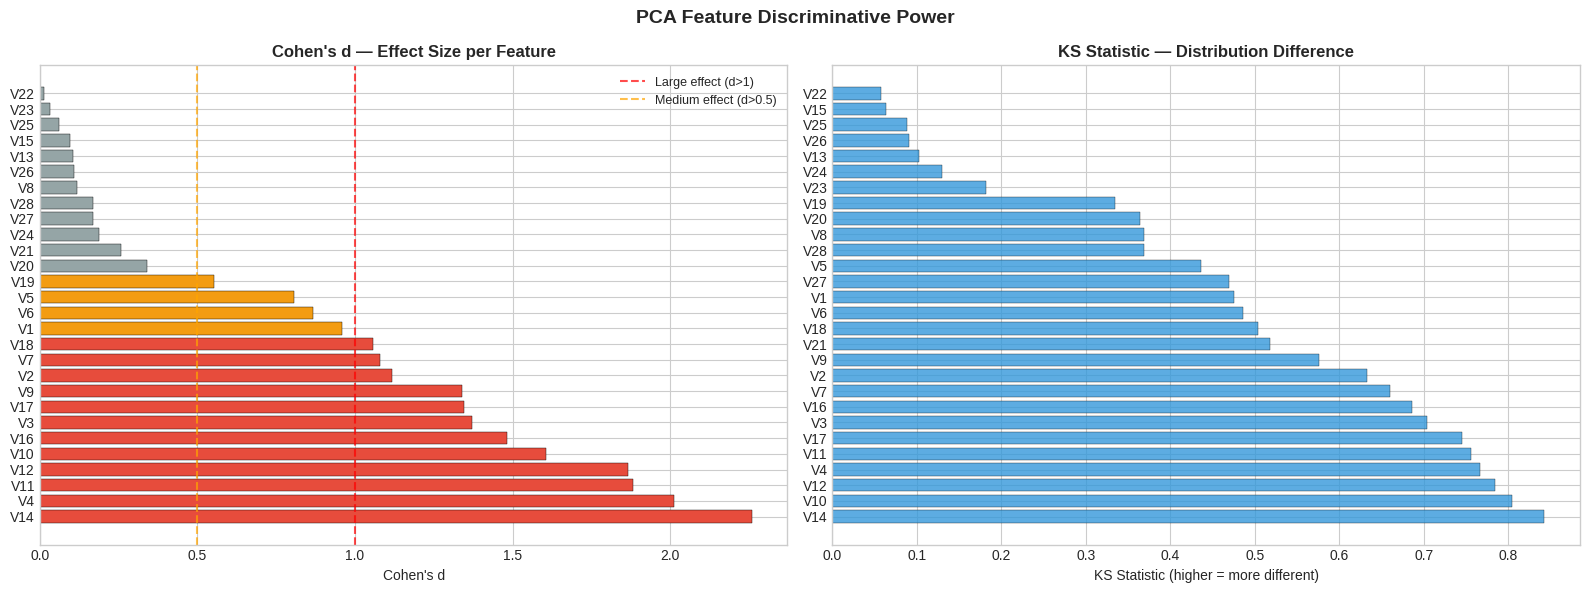

💡 TOP 10 MOST DISCRIMINATIVE FEATURES
['V14', 'V4', 'V11', 'V12', 'V10', 'V16', 'V3', 'V17', 'V9', 'V2']

→ Fitur-fitur ini paling membedakan fraud vs normal
→ Kita simpan list ini — akan dipakai untuk analisis SHAP nanti


In [8]:
# ============================================================
# PCA Features Analysis — Mana yang paling diskriminatif?
# ============================================================

v_features = [f'V{i}' for i in range(1, 29)]

# Hitung statistical separation untuk setiap fitur V
separation_stats = []
for feat in v_features:
    normal_vals = normal_df[feat]
    fraud_vals  = fraud_df[feat]

    # Effect size menggunakan Cohen's d
    pooled_std = np.sqrt((normal_vals.std()**2 + fraud_vals.std()**2) / 2)
    cohens_d   = abs(normal_vals.mean() - fraud_vals.mean()) / pooled_std

    # KS test — seberapa berbeda distribusinya
    ks_stat, ks_pval = stats.ks_2samp(normal_vals, fraud_vals)

    separation_stats.append({
        'feature'   : feat,
        'cohens_d'  : cohens_d,
        'ks_stat'   : ks_stat,
        'ks_pvalue' : ks_pval,
        'mean_diff' : abs(normal_vals.mean() - fraud_vals.mean())
    })

sep_df = pd.DataFrame(separation_stats).sort_values('cohens_d', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PCA Feature Discriminative Power', fontsize=14, fontweight='bold')

# --- Plot 1: Cohen's d (effect size) ---
colors = ['#e74c3c' if d > 1.0 else '#f39c12' if d > 0.5 else '#95a5a6'
          for d in sep_df['cohens_d']]
axes[0].barh(sep_df['feature'], sep_df['cohens_d'],
             color=colors, edgecolor='black', linewidth=0.3)
axes[0].axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='Large effect (d>1)')
axes[0].axvline(x=0.5, color='orange', linestyle='--', alpha=0.7, label='Medium effect (d>0.5)')
axes[0].set_title("Cohen's d — Effect Size per Feature", fontweight='bold')
axes[0].set_xlabel("Cohen's d")
axes[0].legend(fontsize=9)

# --- Plot 2: KS Statistic ---
sep_df_ks = sep_df.sort_values('ks_stat', ascending=False)
axes[1].barh(sep_df_ks['feature'], sep_df_ks['ks_stat'],
             color='#3498db', alpha=0.8, edgecolor='black', linewidth=0.3)
axes[1].set_title('KS Statistic — Distribution Difference', fontweight='bold')
axes[1].set_xlabel('KS Statistic (higher = more different)')

plt.tight_layout()
plt.savefig('feature_discrimination.png', dpi=150, bbox_inches='tight')
plt.show()

# Top features
top_features = sep_df.head(10)['feature'].tolist()
print("=" * 60)
print("💡 TOP 10 MOST DISCRIMINATIVE FEATURES")
print("=" * 60)
print(top_features)
print("\n→ Fitur-fitur ini paling membedakan fraud vs normal")
print("→ Kita simpan list ini — akan dipakai untuk analisis SHAP nanti")

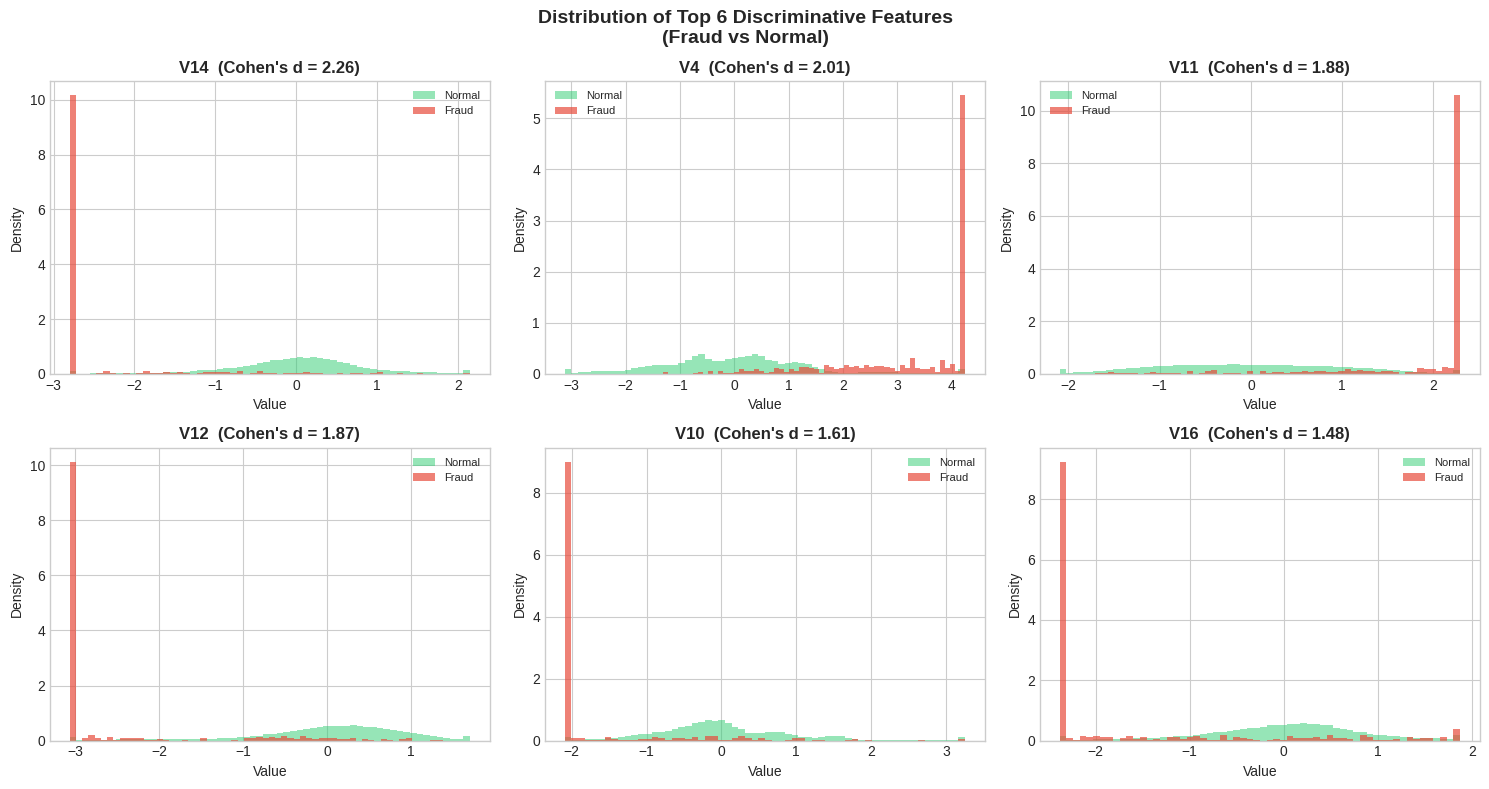

💡 Semakin sedikit overlap antara dua distribusi,
   semakin powerful fitur tersebut untuk deteksi fraud.


In [9]:
# ============================================================
# Distribution Plot — Top 6 Most Discriminative Features
# ============================================================

top_6 = sep_df.head(6)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribution of Top 6 Discriminative Features\n(Fraud vs Normal)',
             fontsize=14, fontweight='bold')

for idx, (feat, ax) in enumerate(zip(top_6, axes.flatten())):
    # Clip outliers untuk visualisasi lebih jelas
    p1, p99 = df[feat].quantile([0.01, 0.99])

    ax.hist(normal_df[feat].clip(p1, p99), bins=60, alpha=0.5,
            color='#2ecc71', label='Normal', density=True)
    ax.hist(fraud_df[feat].clip(p1, p99), bins=60, alpha=0.7,
            color='#e74c3c', label='Fraud', density=True)

    d_val = sep_df[sep_df['feature'] == feat]['cohens_d'].values[0]
    ax.set_title(f"{feat}  (Cohen's d = {d_val:.2f})", fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('top_features_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 Semakin sedikit overlap antara dua distribusi,")
print("   semakin powerful fitur tersebut untuk deteksi fraud.")

### 2.4 Correlation Heatmap

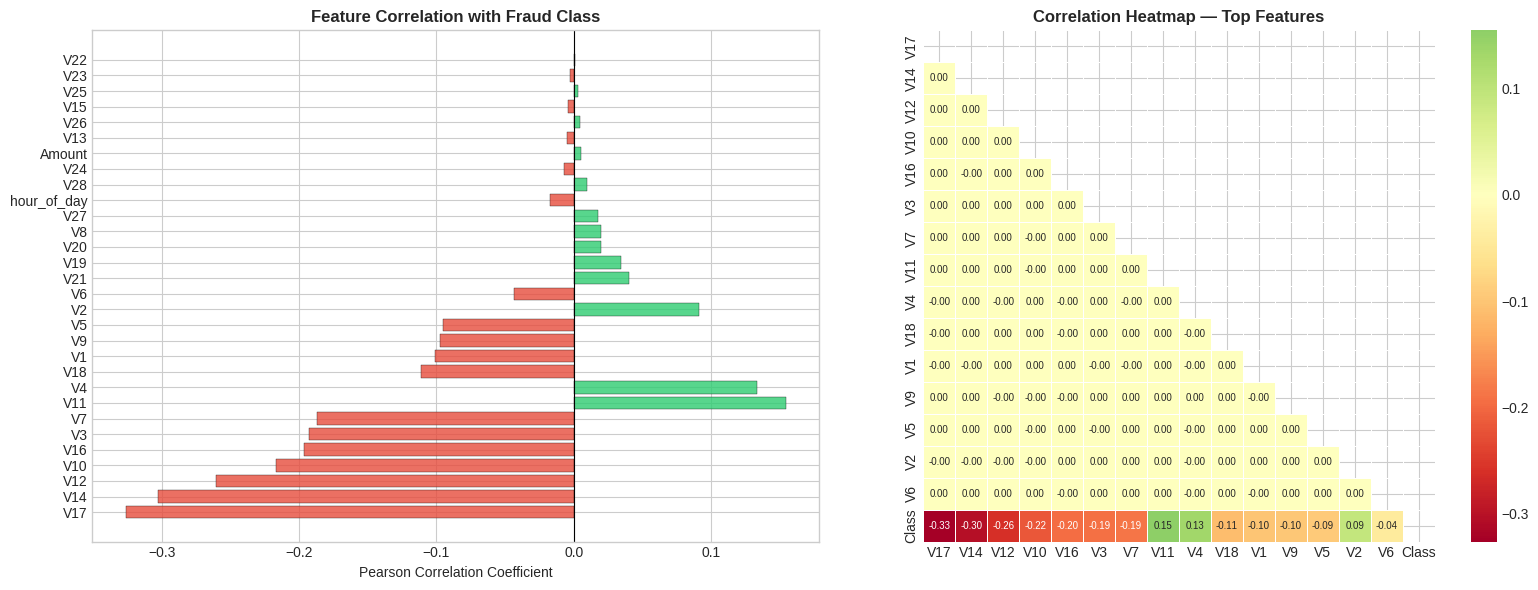

💡 KEY INSIGHTS - Correlation
Fitur dengan korelasi NEGATIF kuat terhadap fraud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539

Fitur dengan korelasi POSITIF kuat terhadap fraud:
V11    0.154876
V4     0.133447

→ Korelasi negatif: nilai tinggi = kemungkinan normal
→ Korelasi positif: nilai tinggi = kemungkinan fraud


In [10]:
# ============================================================
# Correlation Analysis — Fraud vs Features
# ============================================================

# Korelasi setiap fitur terhadap target Class
correlations = df[v_features + ['Amount', 'hour_of_day']].corrwith(df['Class'])
correlations = correlations.sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Correlation bar chart ---
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in correlations.values]
axes[0].barh(correlations.index, correlations.values,
             color=colors, alpha=0.8, edgecolor='black', linewidth=0.3)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_title('Feature Correlation with Fraud Class', fontweight='bold')
axes[0].set_xlabel('Pearson Correlation Coefficient')

# --- Plot 2: Heatmap top features vs Class ---
top_corr_features = correlations.abs().head(15).index.tolist()
corr_matrix = df[top_corr_features + ['Class']].corr()

mask = np.zeros_like(corr_matrix)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, ax=axes[1], mask=mask,
            cmap='RdYlGn', center=0, annot=True, fmt='.2f',
            linewidths=0.5, square=True, annot_kws={'size': 7})
axes[1].set_title('Correlation Heatmap — Top Features', fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("💡 KEY INSIGHTS - Correlation")
print("=" * 60)
print("Fitur dengan korelasi NEGATIF kuat terhadap fraud:")
print(correlations[correlations < -0.1].head(5).to_string())
print("\nFitur dengan korelasi POSITIF kuat terhadap fraud:")
print(correlations[correlations > 0.1].head(5).to_string())
print("\n→ Korelasi negatif: nilai tinggi = kemungkinan normal")
print("→ Korelasi positif: nilai tinggi = kemungkinan fraud")

### 2.5 EDA Summary - Keputusan Teknis

In [11]:
# ============================================================
# CELL 11: EDA Summary & Technical Decisions
# ============================================================

summary = """
               EDA SUMMARY & TECHNICAL DECISIONS
══════════════════════════════════════════════════════════════

  FINDINGS:
  1. Class imbalance: 0.172% fraud — SEVERE
     → Wajib handle dengan resampling + class weighting

  2. Amount: Fraud cenderung nominal KECIL
     → Perlu log-transform Amount (right-skewed)
     → Tambahkan fitur amount_zscore per time window

  3. Time: Fraud lebih tinggi di jam sepi (dini hari)
     → Gunakan hour_of_day sebagai fitur
     → Tambahkan is_night_transaction flag

  4. V Features: V4, V11, V14, V17 paling diskriminatif
     → Semua V features dipertahankan (let LightGBM decide)

  DECISIONS FOR NEXT PHASE:
  ✅ Log-transform Amount
  ✅ Engineer hour_of_day & is_night flag
  ✅ RobustScaler untuk Amount & Time (robust terhadap outlier ekstrem)
  ✅ Metric utama: PR-AUC (bukan ROC-AUC, bukan Accuracy)
  ✅ Imbalanced strategy: Compare 3 approaches

"""
print(summary)

# Simpan top features untuk fase berikutnya
TOP_DISCRIMINATIVE_FEATURES = sep_df.head(10)['feature'].tolist()
print(f"Top features saved: {TOP_DISCRIMINATIVE_FEATURES}")


               EDA SUMMARY & TECHNICAL DECISIONS
══════════════════════════════════════════════════════════════

  FINDINGS:
  1. Class imbalance: 0.172% fraud — SEVERE
     → Wajib handle dengan resampling + class weighting

  2. Amount: Fraud cenderung nominal KECIL
     → Perlu log-transform Amount (right-skewed)
     → Tambahkan fitur amount_zscore per time window

  3. Time: Fraud lebih tinggi di jam sepi (dini hari)
     → Gunakan hour_of_day sebagai fitur
     → Tambahkan is_night_transaction flag

  4. V Features: V4, V11, V14, V17 paling diskriminatif
     → Semua V features dipertahankan (let LightGBM decide)

  DECISIONS FOR NEXT PHASE:
  ✅ Log-transform Amount
  ✅ Engineer hour_of_day & is_night flag
  ✅ RobustScaler untuk Amount & Time (robust terhadap outlier ekstrem)
  ✅ Metric utama: PR-AUC (bukan ROC-AUC, bukan Accuracy)
  ✅ Imbalanced strategy: Compare 3 approaches


Top features saved: ['V14', 'V4', 'V11', 'V12', 'V10', 'V16', 'V3', 'V17', 'V9', 'V2']


In [12]:
# ============================================================
# CELL CLEANUP — Drop temporary EDA columns sebelum Fase 3
# ============================================================
eda_temp_cols = ['amount_bucket', 'time_block', 'hour_bin', 'hour_of_day']
df.drop(columns=[c for c in eda_temp_cols if c in df.columns], inplace=True)
print("✅ Temporary EDA columns removed. df shape:", df.shape)

✅ Temporary EDA columns removed. df shape: (284807, 31)


## FASE 3: Feature Engineering
---

### 3.1 Feature Engineering Plan

In [13]:
# ============================================================
# Feature Engineering Roadmap
# ============================================================

plan = """
FEATURE ENGINEERING PLAN
=========================
Berdasarkan EDA, kita akan membuat 3 kelompok fitur baru:

1. AMOUNT FEATURES
   → log_amount        : Log transform untuk handle right-skew
   → amount_zscore     : Seberapa "aneh" nominal ini secara statistik
   → is_small_amount   : Flag transaksi kecil (<= €10, pola card testing)
   → is_large_amount   : Flag transaksi besar (>= €1000)

2. TEMPORAL FEATURES
   → hour_of_day       : Jam transaksi (sudah dibuat di EDA)
   → is_night          : Flag jam 00:00–06:00 (high fraud period)
   → is_weekend        : Estimasi hari weekend dari Time
   → time_sin / cos    : Cyclic encoding untuk jam (mencegah 23→0 jump)

3. INTERACTION FEATURES
   → amount_x_night    : Transaksi besar di malam hari = risiko tinggi
   → v_fraud_score     : Composite score dari top discriminative V features

CATATAN:
   V1-V28 TIDAK dimodifikasi — sudah dalam PCA space.
   Modifikasi V features akan merusak makna geometrisnya.
"""
print(plan)


FEATURE ENGINEERING PLAN
Berdasarkan EDA, kita akan membuat 3 kelompok fitur baru:

1. AMOUNT FEATURES
   → log_amount        : Log transform untuk handle right-skew
   → amount_zscore     : Seberapa "aneh" nominal ini secara statistik
   → is_small_amount   : Flag transaksi kecil (<= €10, pola card testing)
   → is_large_amount   : Flag transaksi besar (>= €1000)

2. TEMPORAL FEATURES
   → hour_of_day       : Jam transaksi (sudah dibuat di EDA)
   → is_night          : Flag jam 00:00–06:00 (high fraud period)
   → is_weekend        : Estimasi hari weekend dari Time
   → time_sin / cos    : Cyclic encoding untuk jam (mencegah 23→0 jump)

3. INTERACTION FEATURES
   → amount_x_night    : Transaksi besar di malam hari = risiko tinggi
   → v_fraud_score     : Composite score dari top discriminative V features

CATATAN:
   V1-V28 TIDAK dimodifikasi — sudah dalam PCA space.
   Modifikasi V features akan merusak makna geometrisnya.



### 3.2 Amount Features

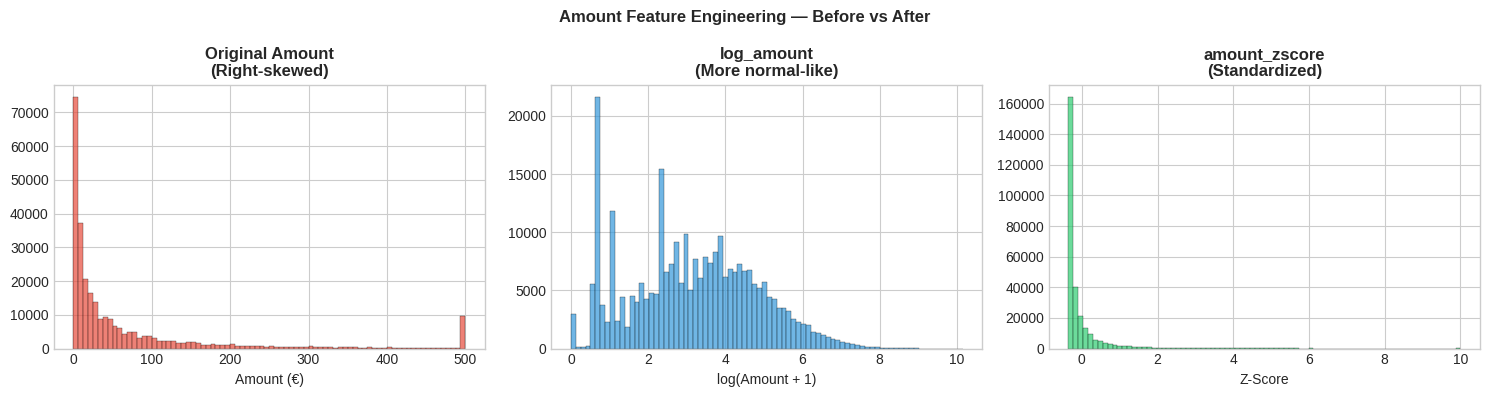

DISCRIMINATIVE POWER — Amount Features vs Fraud
  Amount               → correlation with fraud: +0.0056
  log_amount           → correlation with fraud: -0.0083
  amount_zscore        → correlation with fraud: +0.0056
  is_small_amount      → correlation with fraud: +0.0134
  is_large_amount      → correlation with fraud: +0.0030

💡 log_amount dan amount_zscore harus lebih korelasi
   dengan fraud dibanding raw Amount.


In [14]:
# ============================================================
# Amount Feature Engineering
# ============================================================

df_fe = df.copy()  # Selalu kerja di copy, preserve original

# 1. Log Transform
df_fe['log_amount'] = np.log1p(df_fe['Amount'])

# 2. Amount Z-Score
amount_mean = df_fe['Amount'].mean()
amount_std  = df_fe['Amount'].std()
df_fe['amount_zscore'] = (df_fe['Amount'] - amount_mean) / amount_std

# 3. Binary Flags
df_fe['is_small_amount'] = (df_fe['Amount'] <= 10).astype(int)
df_fe['is_large_amount'] = (df_fe['Amount'] >= 1000).astype(int)

# Validasi & visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Amount Feature Engineering — Before vs After', fontweight='bold')

# Original Amount
axes[0].hist(df_fe['Amount'].clip(upper=500), bins=80,
             color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=0.3)
axes[0].set_title('Original Amount\n(Right-skewed)', fontweight='bold')
axes[0].set_xlabel('Amount (€)')

# Log Amount
axes[1].hist(df_fe['log_amount'], bins=80,
             color='#3498db', alpha=0.7, edgecolor='black', linewidth=0.3)
axes[1].set_title('log_amount\n(More normal-like)', fontweight='bold')
axes[1].set_xlabel('log(Amount + 1)')

# Z-Score
axes[2].hist(df_fe['amount_zscore'].clip(-3, 10), bins=80,
             color='#2ecc71', alpha=0.7, edgecolor='black', linewidth=0.3)
axes[2].set_title('amount_zscore\n(Standardized)', fontweight='bold')
axes[2].set_xlabel('Z-Score')

plt.tight_layout()
plt.savefig('amount_features.png', dpi=150, bbox_inches='tight')
plt.show()

# Cek efektivitas: apakah fitur baru lebih diskriminatif?
print("=" * 55)
print("DISCRIMINATIVE POWER — Amount Features vs Fraud")
print("=" * 55)
new_amount_feats = ['Amount', 'log_amount', 'amount_zscore',
                    'is_small_amount', 'is_large_amount']
for feat in new_amount_feats:
    corr = df_fe[feat].corr(df_fe['Class'])
    print(f"  {feat:<20} → correlation with fraud: {corr:+.4f}")

print("\n💡 log_amount dan amount_zscore harus lebih korelasi")
print("   dengan fraud dibanding raw Amount.")

### 3.3 Temporal Features

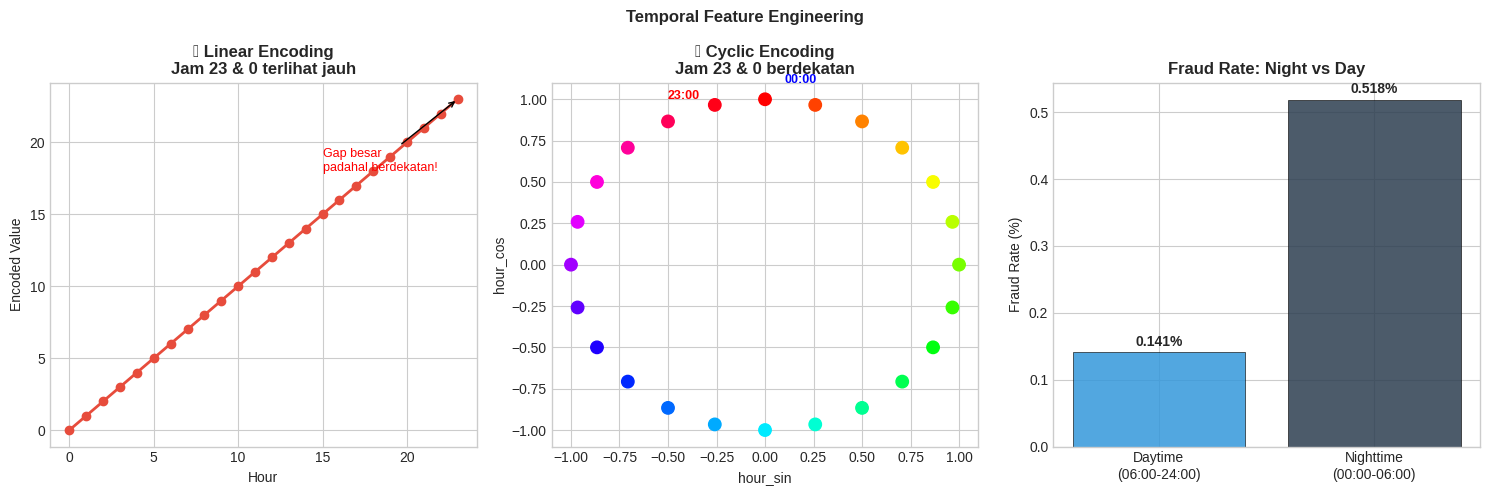


💡 Night fraud rate  : 0.518%
   Day fraud rate    : 0.141%
   Night multiplier  : 3.7x lebih tinggi


In [15]:
# ============================================================
# Temporal Feature Engineering
# ============================================================

# 1. Hour of Day (sudah ada, pastikan ada)
if 'hour_of_day' not in df_fe.columns:
    df_fe['hour_of_day'] = (df_fe['Time'] / 3600) % 24

# 2. Night Flag
df_fe['is_night'] = ((df_fe['hour_of_day'] >= 0) &
                     (df_fe['hour_of_day'] < 6)).astype(int)

# 3. Cyclic Encoding untuk Hour
df_fe['hour_sin'] = np.sin(2 * np.pi * df_fe['hour_of_day'] / 24)
df_fe['hour_cos'] = np.cos(2 * np.pi * df_fe['hour_of_day'] / 24)

# 4. Weekend Estimation
# day_of_week hanya intermediate — tidak dimasukkan ke model
# yang dipakai adalah is_weekend (binary flag)
df_fe['day_of_week'] = (df_fe['Time'] // (3600 * 24)) % 7
df_fe['is_weekend']  = (df_fe['day_of_week'] >= 5).astype(int)

# 5. Time Since Last Transaction
df_fe['time_diff'] = df_fe['Time'].diff().fillna(0)
df_fe['time_diff_log'] = np.log1p(df_fe['time_diff'])

# Visualisasi cyclic encoding
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Temporal Feature Engineering', fontweight='bold')

# Linear encoding problem
hours = np.arange(24)
axes[0].plot(hours, hours, 'o-', color='#e74c3c', linewidth=2)
axes[0].set_title('❌ Linear Encoding\nJam 23 & 0 terlihat jauh', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Encoded Value')
axes[0].annotate('Gap besar\npadahal berdekatan!',
                 xy=(23, 23), xytext=(15, 18),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=9, color='red')

# Cyclic encoding solution
theta = 2 * np.pi * hours / 24
axes[1].scatter(np.sin(theta), np.cos(theta),
                c=hours, cmap='hsv', s=80, zorder=3)
axes[1].set_title('✅ Cyclic Encoding\nJam 23 & 0 berdekatan', fontweight='bold')
axes[1].set_xlabel('hour_sin')
axes[1].set_ylabel('hour_cos')
# Annotasi jam 0 dan jam 23
axes[1].annotate('00:00', xy=(np.sin(0), np.cos(0)),
                 xytext=(0.1, 1.1), fontsize=9, color='blue', fontweight='bold')
axes[1].annotate('23:00', xy=(np.sin(2*np.pi*23/24), np.cos(2*np.pi*23/24)),
                 xytext=(-0.5, 1.0), fontsize=9, color='red', fontweight='bold')

# Fraud rate: night vs day
night_fraud = df_fe[df_fe['is_night'] == 1]['Class'].mean() * 100
day_fraud   = df_fe[df_fe['is_night'] == 0]['Class'].mean() * 100
axes[2].bar(['Daytime\n(06:00-24:00)', 'Nighttime\n(00:00-06:00)'],
            [day_fraud, night_fraud],
            color=['#3498db', '#2c3e50'], alpha=0.85,
            edgecolor='black', linewidth=0.5)
axes[2].set_title('Fraud Rate: Night vs Day', fontweight='bold')
axes[2].set_ylabel('Fraud Rate (%)')
for i, v in enumerate([day_fraud, night_fraud]):
    axes[2].text(i, v + 0.01, f'{v:.3f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('temporal_features.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n💡 Night fraud rate  : {night_fraud:.3f}%")
print(f"   Day fraud rate    : {day_fraud:.3f}%")
print(f"   Night multiplier  : {night_fraud/day_fraud:.1f}x lebih tinggi")

### 3.4 Interaction Features

INTERACTION FEATURES — Fraud Rate Check

  large_amount_at_night:
    Count     : 131 transactions
    Fraud rate: 1.527%  (vs baseline 0.173%)
    Lift      : 8.8x

  small_amount_at_night:
    Count     : 9,154 transactions
    Fraud rate: 0.874%  (vs baseline 0.173%)
    Lift      : 5.1x


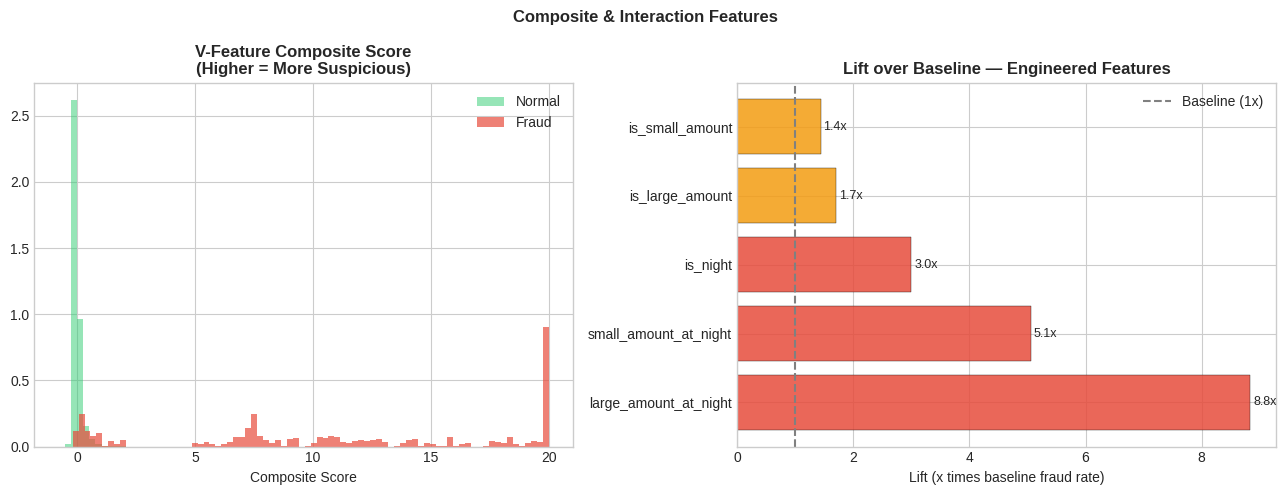

In [16]:
# ============================================================
# Interaction & Composite Features
# ============================================================

# 1. High-Risk Interaction
df_fe['large_amount_at_night'] = (
    (df_fe['is_large_amount'] == 1) &
    (df_fe['is_night'] == 1)
).astype(int)

# 2. Small Amount at Night (card testing pattern)
df_fe['small_amount_at_night'] = (
    (df_fe['is_small_amount'] == 1) &
    (df_fe['is_night'] == 1)
).astype(int)

# 3. V-Feature Composite Fraud Score
v_features = [f'V{i}' for i in range(1, 29)]
v_correlations = df_fe[v_features].corrwith(df_fe['Class'])

# Composite score: weighted sum (dengan memperhitungkan arah korelasi)
df_fe['v_fraud_composite'] = sum(
    df_fe[feat] * v_correlations[feat]
    for feat in v_features
)

# Validasi interaction features
print("=" * 55)
print("INTERACTION FEATURES — Fraud Rate Check")
print("=" * 55)

interaction_feats = ['large_amount_at_night', 'small_amount_at_night']
for feat in interaction_feats:
    total   = df_fe[feat].sum()
    fr_rate = df_fe[df_fe[feat] == 1]['Class'].mean() * 100
    print(f"\n  {feat}:")
    print(f"    Count     : {total:,} transactions")
    print(f"    Fraud rate: {fr_rate:.3f}%  (vs baseline {df_fe['Class'].mean()*100:.3f}%)")
    print(f"    Lift      : {fr_rate / (df_fe['Class'].mean()*100):.1f}x")

# Visualisasi composite score
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Composite & Interaction Features', fontweight='bold')

# V composite score distribution
axes[0].hist(df_fe[df_fe['Class']==0]['v_fraud_composite'].clip(-20, 20),
             bins=80, alpha=0.5, color='#2ecc71',
             label='Normal', density=True)
axes[0].hist(df_fe[df_fe['Class']==1]['v_fraud_composite'].clip(-20, 20),
             bins=80, alpha=0.7, color='#e74c3c',
             label='Fraud', density=True)
axes[0].set_title('V-Feature Composite Score\n(Higher = More Suspicious)',
                  fontweight='bold')
axes[0].set_xlabel('Composite Score')
axes[0].legend()

# Lift chart untuk interaction features
all_feats_lift = {}
check_feats = ['is_small_amount', 'is_large_amount', 'is_night',
               'is_weekend', 'large_amount_at_night', 'small_amount_at_night']
baseline = df_fe['Class'].mean() * 100

for feat in check_feats:
    rate = df_fe[df_fe[feat] == 1]['Class'].mean() * 100
    all_feats_lift[feat] = rate / baseline

lift_series = pd.Series(all_feats_lift).sort_values(ascending=False)
colors = ['#e74c3c' if v > 2 else '#f39c12' if v > 1 else '#95a5a6'
          for v in lift_series.values]

axes[1].barh(lift_series.index, lift_series.values,
             color=colors, alpha=0.85, edgecolor='black', linewidth=0.3)
axes[1].axvline(x=1.0, color='gray', linestyle='--', label='Baseline (1x)')
axes[1].set_title('Lift over Baseline — Engineered Features',
                  fontweight='bold')
axes[1].set_xlabel('Lift (x times baseline fraud rate)')
axes[1].legend()
for i, v in enumerate(lift_series.values):
    axes[1].text(v + 0.05, i, f'{v:.1f}x', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('interaction_features.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Final Feature Set & Preprocessing

In [17]:
# ============================================================
# Finalize Feature Set & Preprocessing Pipeline
# ============================================================

from sklearn.preprocessing import StandardScaler, RobustScaler

# Definisi final feature columns
V_FEATURES       = [f'V{i}' for i in range(1, 29)]
AMOUNT_FEATURES  = ['log_amount', 'amount_zscore',
                    'is_small_amount', 'is_large_amount']
TEMPORAL_FEATURES = ['hour_of_day', 'hour_sin', 'hour_cos',
                     'is_night', 'is_weekend', 'time_diff_log']
INTERACTION_FEATURES = ['large_amount_at_night',
                        'small_amount_at_night',
                        'v_fraud_composite']

ALL_FEATURES = V_FEATURES + AMOUNT_FEATURES + TEMPORAL_FEATURES + INTERACTION_FEATURES
TARGET       = 'Class'

print(f"Total features: {len(ALL_FEATURES)}")
print(f"\nBreakdown:")
print(f"  V features          : {len(V_FEATURES)}")
print(f"  Amount features     : {len(AMOUNT_FEATURES)}")
print(f"  Temporal features   : {len(TEMPORAL_FEATURES)}")
print(f"  Interaction features: {len(INTERACTION_FEATURES)}")

Total features: 41

Breakdown:
  V features          : 28
  Amount features     : 4
  Temporal features   : 6
  Interaction features: 3


In [18]:
# ============================================================
# Train-Test Split (Stratified)
# ============================================================

X = df_fe[ALL_FEATURES]
y = df_fe[TARGET]

# Stratified split — WAJIB untuk imbalanced data
# Memastikan proporsi fraud sama di train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y          # ← Key parameter untuk imbalanced data
)

print("=" * 55)
print("TRAIN-TEST SPLIT (Stratified)")
print("=" * 55)
print(f"\nTrain set: {X_train.shape[0]:,} samples")
print(f"  Normal : {(y_train == 0).sum():,} ({(y_train==0).mean()*100:.3f}%)")
print(f"  Fraud  : {(y_train == 1).sum():,} ({(y_train==1).mean()*100:.3f}%)")
print(f"\nTest set : {X_test.shape[0]:,} samples")
print(f"  Normal : {(y_test == 0).sum():,} ({(y_test==0).mean()*100:.3f}%)")
print(f"  Fraud  : {(y_test == 1).sum():,} ({(y_test==1).mean()*100:.3f}%)")
print(f"\n✅ Proporsi fraud terjaga di train & test (stratified)")

TRAIN-TEST SPLIT (Stratified)

Train set: 227,845 samples
  Normal : 227,451 (99.827%)
  Fraud  : 394 (0.173%)

Test set : 56,962 samples
  Normal : 56,864 (99.828%)
  Fraud  : 98 (0.172%)

✅ Proporsi fraud terjaga di train & test (stratified)


In [19]:
# ============================================================
# Scaling — Hanya untuk fitur yang butuh scaling
# ============================================================
SCALE_FEATURES = ['log_amount', 'amount_zscore', 'hour_of_day',
                  'time_diff_log', 'v_fraud_composite']

scaler = RobustScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[SCALE_FEATURES] = scaler.fit_transform(X_train[SCALE_FEATURES])
X_test_scaled[SCALE_FEATURES]  = scaler.transform(X_test[SCALE_FEATURES])

print("✅ Scaling applied dengan RobustScaler")
print(f"   Features scaled: {SCALE_FEATURES}")
print(f"\n💡 RobustScaler dipilih karena:")
print(f"   → Menggunakan median & IQR, bukan mean & std")
print(f"   → Lebih robust terhadap outlier ekstrem")
print(f"   → Data keuangan sering punya extreme transaction values")
print(f"\n⚠️  fit() HANYA pada train set, transform() pada keduanya")
print(f"   Mencegah data leakage dari test set ke train set")

✅ Scaling applied dengan RobustScaler
   Features scaled: ['log_amount', 'amount_zscore', 'hour_of_day', 'time_diff_log', 'v_fraud_composite']

💡 RobustScaler dipilih karena:
   → Menggunakan median & IQR, bukan mean & std
   → Lebih robust terhadap outlier ekstrem
   → Data keuangan sering punya extreme transaction values

⚠️  fit() HANYA pada train set, transform() pada keduanya
   Mencegah data leakage dari test set ke train set


In [20]:
# ============================================================
# Feature Engineering Validation & Summary
# ============================================================

# Cek korelasi semua fitur baru vs target
new_features_corr = pd.Series({
    feat: X_train_scaled[feat].corr(y_train)
    for feat in ALL_FEATURES
}).sort_values(key=abs, ascending=False)

print("=" * 55)
print("TOP 15 FEATURES BY CORRELATION WITH FRAUD")
print("=" * 55)
print(new_features_corr.head(15).to_string())

# Simpan artifacts untuk fase berikutnya
import joblib

# Simpan scaler untuk digunakan di inference nanti
joblib.dump(scaler, 'robust_scaler.pkl')
joblib.dump(ALL_FEATURES, 'feature_columns.pkl')

print("\n" + "=" * 55)
print("✅ FASE 3 COMPLETE — ARTIFACTS SAVED")
print("=" * 55)
print("  robust_scaler.pkl    → Scaler untuk inference")
print("  feature_columns.pkl  → Feature list")
print(f"\n  Ready for modeling with {len(ALL_FEATURES)} features")
print(f"  Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")

TOP 15 FEATURES BY CORRELATION WITH FRAUD
v_fraud_composite    0.707168
V17                 -0.321937
V14                 -0.301054
V12                 -0.259989
V10                 -0.217894
V3                  -0.194135
V16                 -0.193826
V7                  -0.186184
V11                  0.153709
V4                   0.135014
V18                 -0.108732
V1                  -0.100041
V9                  -0.098247
V5                  -0.093578
V2                   0.090586

✅ FASE 3 COMPLETE — ARTIFACTS SAVED
  robust_scaler.pkl    → Scaler untuk inference
  feature_columns.pkl  → Feature list

  Ready for modeling with 41 features
  Train: (227845, 41), Test: (56962, 41)


## FASE 4: Modelling & Imbalanced Handling
---

### 4.1 Kerangka Evaluasi

In [21]:
# ============================================================
# Evaluation Framework
# ============================================================

from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_curve, roc_curve,
    average_precision_score, roc_auc_score
)

def evaluate_model(model, X_test, y_test, model_name="Model", threshold=0.5):
    """
    Fungsi evaluasi standar yang dipakai konsisten di semua model.
    Mengembalikan dict metrics untuk perbandingan antar model.
    """
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    metrics = {
        'model_name'  : model_name,
        'threshold'   : threshold,
        'precision'   : precision_score(y_test, y_pred, zero_division=0),
        'recall'      : recall_score(y_test, y_pred),
        'f1'          : f1_score(y_test, y_pred),
        'roc_auc'     : roc_auc_score(y_test, y_prob),
        'pr_auc'      : average_precision_score(y_test, y_prob),
        'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn,
        'y_prob'      : y_prob  # simpan untuk plotting
    }
    return metrics


def print_metrics(metrics):
    """Pretty print hasil evaluasi."""
    print(f"\n{'='*55}")
    print(f"  {metrics['model_name']} (threshold={metrics['threshold']})")
    print(f"{'='*55}")
    print(f"  PR-AUC    : {metrics['pr_auc']:.4f}  ← METRIK UTAMA")
    print(f"  ROC-AUC   : {metrics['roc_auc']:.4f}")
    print(f"  Precision : {metrics['precision']:.4f}")
    print(f"  Recall    : {metrics['recall']:.4f}")
    print(f"  F1-Score  : {metrics['f1']:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"  TP={metrics['tp']:,}  FP={metrics['fp']:,}")
    print(f"  FN={metrics['fn']:,}  TN={metrics['tn']:,}")
    print(f"\n  → Fraud tertangkap  : {metrics['tp']:,} / {metrics['tp']+metrics['fn']:,}")
    print(f"  → Nasabah terganggu : {metrics['fp']:,} false alarms")


def plot_pr_roc(metrics_list, title="Model Comparison"):
    """Plot PR curve dan ROC curve untuk semua model sekaligus."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

    for i, m in enumerate(metrics_list):
        color = colors[i % len(colors)]
        y_prob = m['y_prob']

        # PR Curve
        prec, rec, _ = precision_recall_curve(y_test, y_prob)
        axes[0].plot(rec, prec, color=color, linewidth=2,
                     label=f"{m['model_name']} (PR-AUC={m['pr_auc']:.3f})")

        # ROC Curve
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        axes[1].plot(fpr, tpr, color=color, linewidth=2,
                     label=f"{m['model_name']} (AUC={m['roc_auc']:.3f})")

    # PR baseline
    baseline = y_test.mean()
    axes[0].axhline(y=baseline, color='gray', linestyle='--',
                    label=f'Baseline ({baseline:.3f})')
    axes[0].set_xlabel('Recall')
    axes[0].set_ylabel('Precision')
    axes[0].set_title('Precision-Recall Curve', fontweight='bold')
    axes[0].legend(fontsize=8)

    # ROC diagonal
    axes[1].plot([0,1], [0,1], 'k--', label='Random classifier')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve', fontweight='bold')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f'{"_".join(title.lower().split())}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

print("✅ Evaluation framework ready")
print("   Fungsi: evaluate_model(), print_metrics(), plot_pr_roc()")

✅ Evaluation framework ready
   Fungsi: evaluate_model(), print_metrics(), plot_pr_roc()


### 4.2 Baseline Model - Logistic Regression


In [22]:
# ============================================================
# Baseline — Logistic Regression (No Handling)
# ============================================================

print("Training Baseline Logistic Regression...")
start = time.time()

lr_baseline = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)
lr_baseline.fit(X_train_scaled, y_train)

elapsed = time.time() - start
print(f"✅ Training selesai dalam {elapsed:.2f} detik")

# Evaluasi
metrics_lr_baseline = evaluate_model(
    lr_baseline, X_test_scaled, y_test,
    model_name="LR Baseline (No Handling)"
)
print_metrics(metrics_lr_baseline)

print(f"""
💡 INTERPRETASI BASELINE:
   Model ini TIDAK menangani imbalanced data sama sekali.
   Hasilnya menjadi patokan — semua model berikutnya
   harus mengalahkan angka PR-AUC di sini.

   Perhatikan Recall yang rendah — model "malas" prediksi fraud
   karena mayoritas data adalah normal.
""")

Training Baseline Logistic Regression...
✅ Training selesai dalam 6.81 detik

  LR Baseline (No Handling) (threshold=0.5)
  PR-AUC    : 0.7445  ← METRIK UTAMA
  ROC-AUC   : 0.9582
  Precision : 0.8025
  Recall    : 0.6633
  F1-Score  : 0.7263

  Confusion Matrix:
  TP=65  FP=16
  FN=33  TN=56,848

  → Fraud tertangkap  : 65 / 98
  → Nasabah terganggu : 16 false alarms

💡 INTERPRETASI BASELINE:
   Model ini TIDAK menangani imbalanced data sama sekali.
   Hasilnya menjadi patokan — semua model berikutnya
   harus mengalahkan angka PR-AUC di sini.

   Perhatikan Recall yang rendah — model "malas" prediksi fraud
   karena mayoritas data adalah normal.



### 4.3 Strategi 1 - Class Weighting

In [23]:
# ============================================================
# Strategi 1 — Class Weighting
# ============================================================

print("="*55)
print("STRATEGI 1: CLASS WEIGHTING")
print("="*55)
print("""
Cara kerja: Model diberi tahu bahwa setiap kesalahan pada
kelas fraud 'lebih mahal' daripada kesalahan pada normal.
Tidak mengubah data — hanya mengubah loss function.

Keuntungan : Cepat, tidak ada data sintetis, tidak overfit
Kelemahan  : Kurang agresif untuk imbalance yang sangat ekstrem
""")

# Hitung class weight otomatis
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}

print(f"Class weights otomatis:")
print(f"  Normal (0) : {weights[0]:.2f}")
print(f"  Fraud  (1) : {weights[1]:.2f}")
print(f"  Ratio      : 1 : {weights[1]/weights[0]:.0f}")

# --- LightGBM dengan Class Weighting ---
start = time.time()

lgb_weighted = lgb.LGBMClassifier(
    n_estimators    = 500,
    learning_rate   = 0.05,
    num_leaves      = 31,
    class_weight    = 'balanced',   # ← Key parameter
    random_state    = RANDOM_STATE,
    n_jobs          = -1,
    verbose         = -1
)
lgb_weighted.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
)

elapsed = time.time() - start
print(f"\n✅ LightGBM (weighted) selesai dalam {elapsed:.2f} detik")

metrics_lgb_weighted = evaluate_model(
    lgb_weighted, X_test_scaled, y_test,
    model_name="LightGBM + Class Weight"
)
print_metrics(metrics_lgb_weighted)

STRATEGI 1: CLASS WEIGHTING

Cara kerja: Model diberi tahu bahwa setiap kesalahan pada
kelas fraud 'lebih mahal' daripada kesalahan pada normal.
Tidak mengubah data — hanya mengubah loss function.

Keuntungan : Cepat, tidak ada data sintetis, tidak overfit
Kelemahan  : Kurang agresif untuk imbalance yang sangat ekstrem

Class weights otomatis:
  Normal (0) : 0.50
  Fraud  (1) : 289.14
  Ratio      : 1 : 577

✅ LightGBM (weighted) selesai dalam 37.26 detik

  LightGBM + Class Weight (threshold=0.5)
  PR-AUC    : 0.8713  ← METRIK UTAMA
  ROC-AUC   : 0.9763
  Precision : 0.9011
  Recall    : 0.8367
  F1-Score  : 0.8677

  Confusion Matrix:
  TP=82  FP=9
  FN=16  TN=56,855

  → Fraud tertangkap  : 82 / 98
  → Nasabah terganggu : 9 false alarms


### 4.4 Strategi 2 - SMOTE Oversampling

In [24]:
# ============================================================
# Strategi 2 — SMOTE
# ============================================================

print("="*55)
print("STRATEGI 2: SMOTE OVERSAMPLING")
print("="*55)
print("""
Cara kerja: Buat sampel sintetis dari kelas minoritas (fraud)
dengan interpolasi antara sampel yang sudah ada di feature space.
BUKAN duplikasi — titik baru dibuat di antara tetangga terdekat.

Keuntungan : Model "melihat" lebih banyak pola fraud
Kelemahan  : Sampel sintetis bisa tidak realistis,
             risiko overfitting jika tidak hati-hati

⚠️  SMOTE hanya boleh diterapkan pada TRAIN SET.
    Test set harus tetap distribusi asli (real-world).
""")

start = time.time()

smote = SMOTE(
    sampling_strategy = 0.1,  # fraud jadi 10% dari normal (bukan 50/50)
    random_state      = RANDOM_STATE,
    k_neighbors       = 5
)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

elapsed = time.time() - start

print(f"✅ SMOTE selesai dalam {elapsed:.2f} detik")
print(f"\nSebelum SMOTE: {y_train.value_counts().to_dict()}")
print(f"Sesudah SMOTE: {pd.Series(y_train_smote).value_counts().to_dict()}")
print(f"Fraud samples ditambah: {(y_train_smote==1).sum() - (y_train==1).sum():,}")

# Train LightGBM di atas data SMOTE
lgb_smote = lgb.LGBMClassifier(
    n_estimators  = 500,
    learning_rate = 0.05,
    num_leaves    = 31,
    random_state  = RANDOM_STATE,
    n_jobs        = -1,
    verbose       = -1
)
lgb_smote.fit(X_train_smote, y_train_smote)

metrics_lgb_smote = evaluate_model(
    lgb_smote, X_test_scaled, y_test,
    model_name="LightGBM + SMOTE"
)
print_metrics(metrics_lgb_smote)

STRATEGI 2: SMOTE OVERSAMPLING

Cara kerja: Buat sampel sintetis dari kelas minoritas (fraud)
dengan interpolasi antara sampel yang sudah ada di feature space.
BUKAN duplikasi — titik baru dibuat di antara tetangga terdekat.

Keuntungan : Model "melihat" lebih banyak pola fraud
Kelemahan  : Sampel sintetis bisa tidak realistis,
             risiko overfitting jika tidak hati-hati

⚠️  SMOTE hanya boleh diterapkan pada TRAIN SET.
    Test set harus tetap distribusi asli (real-world).

✅ SMOTE selesai dalam 0.68 detik

Sebelum SMOTE: {0: 227451, 1: 394}
Sesudah SMOTE: {0: 227451, 1: 22745}
Fraud samples ditambah: 22,351

  LightGBM + SMOTE (threshold=0.5)
  PR-AUC    : 0.8812  ← METRIK UTAMA
  ROC-AUC   : 0.9814
  Precision : 0.9121
  Recall    : 0.8469
  F1-Score  : 0.8783

  Confusion Matrix:
  TP=83  FP=8
  FN=15  TN=56,856

  → Fraud tertangkap  : 83 / 98
  → Nasabah terganggu : 8 false alarms


### 4.5 Strategi 3 - Combined (SMOTE + Class Weight)

In [25]:
# ============================================================
# Strategi 3 — Combined Approach (Best Practice)
# ============================================================

print("="*55)
print("STRATEGI 3: COMBINED — SMOTE + CLASS WEIGHTING")
print("="*55)
print("""
Cara kerja: Gabungkan kedua strategi.
SMOTE menambah sampel fraud di training,
Class weighting memastikan model tetap sensitif saat training.

""")

lgb_combined = lgb.LGBMClassifier(
    n_estimators  = 500,
    learning_rate = 0.05,
    num_leaves    = 31,
    class_weight  = 'balanced',
    random_state  = RANDOM_STATE,
    n_jobs        = -1,
    verbose       = -1
)

# Train di data yang sudah di-SMOTE
lgb_combined.fit(X_train_smote, y_train_smote)

metrics_lgb_combined = evaluate_model(
    lgb_combined, X_test_scaled, y_test,
    model_name="LightGBM + SMOTE + Weight"
)
print_metrics(metrics_lgb_combined)

STRATEGI 3: COMBINED — SMOTE + CLASS WEIGHTING

Cara kerja: Gabungkan kedua strategi.
SMOTE menambah sampel fraud di training,
Class weighting memastikan model tetap sensitif saat training.



  LightGBM + SMOTE + Weight (threshold=0.5)
  PR-AUC    : 0.8834  ← METRIK UTAMA
  ROC-AUC   : 0.9807
  Precision : 0.8925
  Recall    : 0.8469
  F1-Score  : 0.8691

  Confusion Matrix:
  TP=83  FP=10
  FN=15  TN=56,854

  → Fraud tertangkap  : 83 / 98
  → Nasabah terganggu : 10 false alarms


### 4.6 Perbandingan Ketiga Strategi

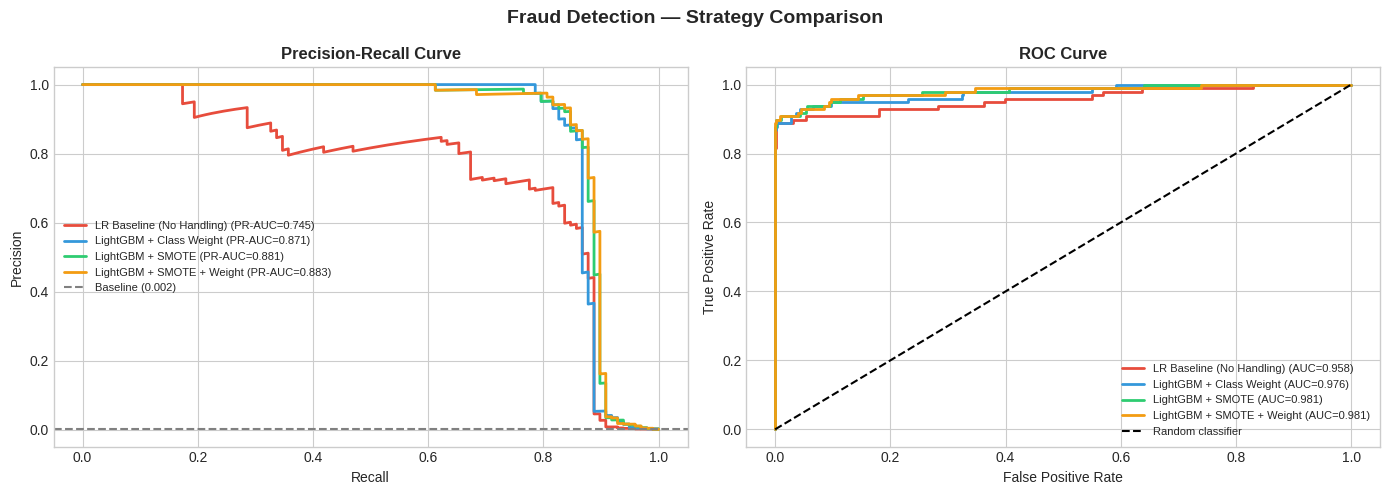


RINGKASAN PERBANDINGAN STRATEGI
                    Model PR-AUC ROC-AUC Recall Precision     F1  TP  FP  FN
LR Baseline (No Handling) 0.7445  0.9582 0.6633    0.8025 0.7263  65  16  33
  LightGBM + Class Weight 0.8713  0.9763 0.8367    0.9011 0.8677  82   9  16
         LightGBM + SMOTE 0.8812  0.9814 0.8469    0.9121 0.8783  83   8  15
LightGBM + SMOTE + Weight 0.8834  0.9807 0.8469    0.8925 0.8691  83  10  15

🏆 Model terbaik berdasarkan PR-AUC: LightGBM + SMOTE + Weight
   PR-AUC: 0.8834


In [26]:
# ============================================================
# Visualisasi Perbandingan Semua Strategi
# ============================================================

all_metrics = [
    metrics_lr_baseline,
    metrics_lgb_weighted,
    metrics_lgb_smote,
    metrics_lgb_combined
]

# Plot PR & ROC curves
plot_pr_roc(all_metrics, title="Fraud Detection — Strategy Comparison")

# Tabel perbandingan
print("\n" + "="*75)
print("RINGKASAN PERBANDINGAN STRATEGI")
print("="*75)

comparison_data = []
for m in all_metrics:
    comparison_data.append({
        'Model'      : m['model_name'],
        'PR-AUC'     : f"{m['pr_auc']:.4f}",
        'ROC-AUC'    : f"{m['roc_auc']:.4f}",
        'Recall'     : f"{m['recall']:.4f}",
        'Precision'  : f"{m['precision']:.4f}",
        'F1'         : f"{m['f1']:.4f}",
        'TP'         : m['tp'],
        'FP'         : m['fp'],
        'FN'         : m['fn'],
    })

comp_df = pd.DataFrame(comparison_data)
print(comp_df.to_string(index=False))

# Tentukan model terbaik berdasarkan PR-AUC
best_idx = np.argmax([m['pr_auc'] for m in all_metrics])
best_model_name = all_metrics[best_idx]['model_name']

print(f"\n🏆 Model terbaik berdasarkan PR-AUC: {best_model_name}")
print(f"   PR-AUC: {all_metrics[best_idx]['pr_auc']:.4f}")

### 4.7 Threshold Tuning


THRESHOLD TUNING
Default threshold = 0.5 artinya: prediksi fraud jika probabilitas > 50%.
Tapi untuk fraud detection, ini TERLALU tinggi.

Kita bisa turunkan threshold untuk menangkap lebih banyak fraud
(meningkatkan Recall), dengan konsekuensi lebih banyak false alarm
(menurunkan Precision).




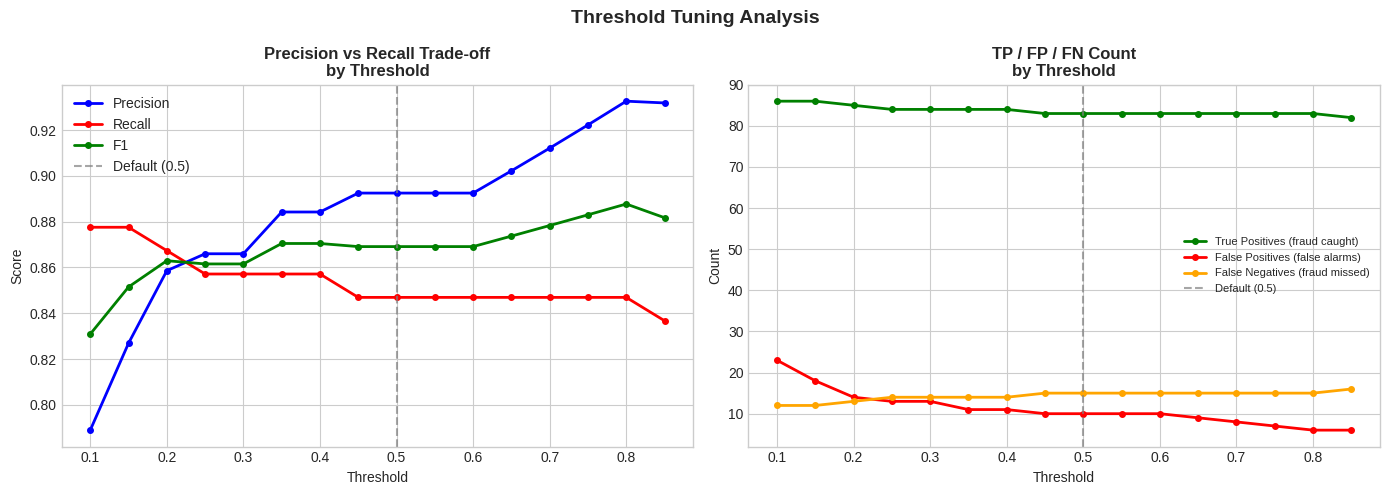

Threshold optimal (max F1) : 0.80
  Precision : 0.9326
  Recall    : 0.8469
  F1        : 0.8877
  TP        : 83
  FP        : 6


In [27]:
# ============================================================
# Threshold Tuning — Ini yang membedakan junior vs senior
# ============================================================

print("""
THRESHOLD TUNING
================
Default threshold = 0.5 artinya: prediksi fraud jika probabilitas > 50%.
Tapi untuk fraud detection, ini TERLALU tinggi.

Kita bisa turunkan threshold untuk menangkap lebih banyak fraud
(meningkatkan Recall), dengan konsekuensi lebih banyak false alarm
(menurunkan Precision).

""")

# Gunakan model terbaik untuk threshold analysis
best_model = [lr_baseline, lgb_weighted, lgb_smote, lgb_combined][best_idx]
best_metrics = all_metrics[best_idx]
y_prob_best  = best_metrics['y_prob']

# Evaluasi di berbagai threshold
thresholds    = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for thresh in thresholds:
    y_pred_t = (y_prob_best >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    threshold_results.append({
        'threshold' : thresh,
        'precision' : precision_score(y_test, y_pred_t, zero_division=0),
        'recall'    : recall_score(y_test, y_pred_t),
        'f1'        : f1_score(y_test, y_pred_t),
        'fp'        : fp,
        'fn'        : fn,
        'tp'        : tp
    })

thresh_df = pd.DataFrame(threshold_results)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Threshold Tuning Analysis', fontsize=14, fontweight='bold')

# Plot 1: Precision-Recall trade-off
axes[0].plot(thresh_df['threshold'], thresh_df['precision'],
             'b-o', markersize=4, linewidth=2, label='Precision')
axes[0].plot(thresh_df['threshold'], thresh_df['recall'],
             'r-o', markersize=4, linewidth=2, label='Recall')
axes[0].plot(thresh_df['threshold'], thresh_df['f1'],
             'g-o', markersize=4, linewidth=2, label='F1')
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.7,
                label='Default (0.5)')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision vs Recall Trade-off\nby Threshold', fontweight='bold')
axes[0].legend()

# Plot 2: TP dan FP per threshold
axes[1].plot(thresh_df['threshold'], thresh_df['tp'],
             'g-o', markersize=4, linewidth=2, label='True Positives (fraud caught)')
axes[1].plot(thresh_df['threshold'], thresh_df['fp'],
             'r-o', markersize=4, linewidth=2, label='False Positives (false alarms)')
axes[1].plot(thresh_df['threshold'], thresh_df['fn'],
             'orange', marker='o', markersize=4, linewidth=2,
             label='False Negatives (fraud missed)')
axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.7,
                label='Default (0.5)')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Count')
axes[1].set_title('TP / FP / FN Count\nby Threshold', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Cari threshold optimal berdasarkan F1
best_thresh_idx = thresh_df['f1'].idxmax()
optimal_threshold = thresh_df.loc[best_thresh_idx, 'threshold']

print(f"Threshold optimal (max F1) : {optimal_threshold:.2f}")
print(f"  Precision : {thresh_df.loc[best_thresh_idx, 'precision']:.4f}")
print(f"  Recall    : {thresh_df.loc[best_thresh_idx, 'recall']:.4f}")
print(f"  F1        : {thresh_df.loc[best_thresh_idx, 'f1']:.4f}")
print(f"  TP        : {thresh_df.loc[best_thresh_idx, 'tp']:,}")
print(f"  FP        : {thresh_df.loc[best_thresh_idx, 'fp']:,}")

### 4.8 Final Evaluation dengan Optimal Threshold


  FINAL — LightGBM + SMOTE + Weight (threshold=0.8000000000000002)
  PR-AUC    : 0.8834  ← METRIK UTAMA
  ROC-AUC   : 0.9807
  Precision : 0.9326
  Recall    : 0.8469
  F1-Score  : 0.8877

  Confusion Matrix:
  TP=83  FP=6
  FN=15  TN=56,858

  → Fraud tertangkap  : 83 / 98
  → Nasabah terganggu : 6 false alarms


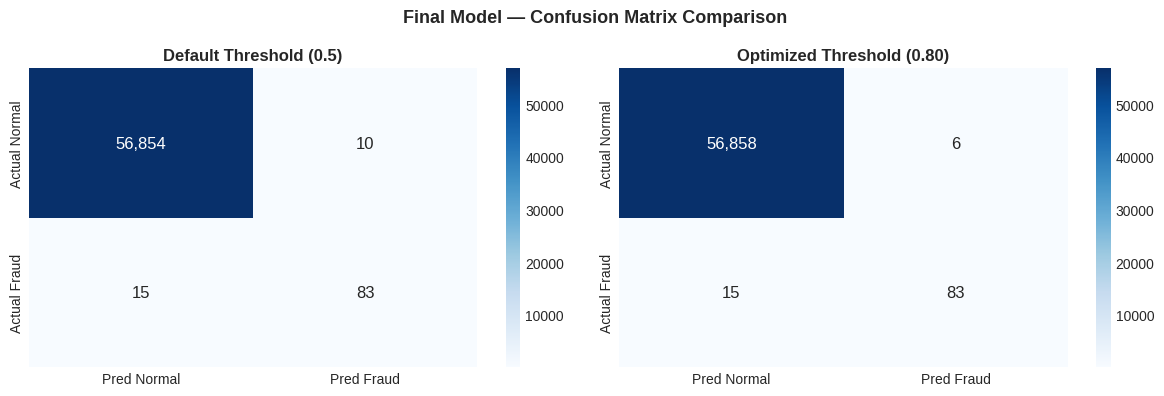


✅ Model final tersimpan:
   fraud_detection_model.pkl
   optimal_threshold.pkl


In [28]:
# ============================================================
# Final Evaluation dengan Optimal Threshold
# ============================================================

# Re-evaluasi model terbaik dengan threshold yang sudah di-tune
model_map = {
    0: lr_baseline,
    1: lgb_weighted,
    2: lgb_smote,
    3: lgb_combined
}
best_model_final = model_map[best_idx]

metrics_final = evaluate_model(
    best_model_final, X_test_scaled, y_test,
    model_name=f"FINAL — {best_model_name}",
    threshold=optimal_threshold
)
print_metrics(metrics_final)

# Visualisasi confusion matrix final
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Final Model — Confusion Matrix Comparison',
             fontsize=13, fontweight='bold')

for ax, (thresh, title_label) in zip(axes, [
    (0.5, 'Default Threshold (0.5)'),
    (optimal_threshold, f'Optimized Threshold ({optimal_threshold:.2f})')
]):
    y_prob = metrics_final['y_prob']
    y_pred = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
                xticklabels=['Pred Normal', 'Pred Fraud'],
                yticklabels=['Actual Normal', 'Actual Fraud'],
                annot_kws={'size': 12})
    ax.set_title(title_label, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Simpan model final
import joblib
joblib.dump(best_model_final, 'fraud_detection_model.pkl')
joblib.dump(optimal_threshold, 'optimal_threshold.pkl')

print("\n✅ Model final tersimpan:")
print("   fraud_detection_model.pkl")
print("   optimal_threshold.pkl")

### 4.9 Fase 4 Summary

In [29]:
# ============================================================
# Fase 4 Summary
# ============================================================

print("=" * 55)
print("           FASE 4 SUMMARY")
print("=" * 55)
print(f"\n  STRATEGI YANG DIBANDINGKAN:")
print(f"  1. LR Baseline          → PR-AUC: {metrics_lr_baseline['pr_auc']:.4f}")
print(f"  2. LightGBM + Weight    → PR-AUC: {metrics_lgb_weighted['pr_auc']:.4f}")
print(f"  3. LightGBM + SMOTE     → PR-AUC: {metrics_lgb_smote['pr_auc']:.4f}")
print(f"  4. LightGBM + Combined  → PR-AUC: {metrics_lgb_combined['pr_auc']:.4f}")
print(f"\n  🏆 MODEL TERPILIH : {best_model_name}")
print(f"  THRESHOLD         : {optimal_threshold:.2f} (dioptimasi dari default 0.5)")
print(f"\n  KEY DECISIONS:")
print(f"  ✅ PR-AUC sebagai metrik utama (bukan accuracy/ROC-AUC)")
print(f"  ✅ Threshold di-tune berdasarkan F1 optimal")
print(f"  ✅ Model & threshold tersimpan untuk inference")
print("=" * 55)

           FASE 4 SUMMARY

  STRATEGI YANG DIBANDINGKAN:
  1. LR Baseline          → PR-AUC: 0.7445
  2. LightGBM + Weight    → PR-AUC: 0.8713
  3. LightGBM + SMOTE     → PR-AUC: 0.8812
  4. LightGBM + Combined  → PR-AUC: 0.8834

  🏆 MODEL TERPILIH : LightGBM + SMOTE + Weight
  THRESHOLD         : 0.80 (dioptimasi dari default 0.5)

  KEY DECISIONS:
  ✅ PR-AUC sebagai metrik utama (bukan accuracy/ROC-AUC)
  ✅ Threshold di-tune berdasarkan F1 optimal
  ✅ Model & threshold tersimpan untuk inference


## FASE 5 - Explainability (SHAP) & Business Impact
---

### 5.1 SHAP Analysis

In [30]:
# ============================================================
# SHAP Setup & Explainer
# ============================================================

import shap

print("Initializing SHAP TreeExplainer...")
print("""
SHAP (SHapley Additive exPlanations)
=====================================
Menjawab pertanyaan: "Mengapa model memutuskan transaksi ini fraud?"

Setiap fitur mendapat SHAP value = kontribusinya terhadap prediksi.
→ SHAP positif : mendorong prediksi ke arah FRAUD
→ SHAP negatif : mendorong prediksi ke arah NORMAL
→ Besarnya nilai = seberapa kuat pengaruhnya
""")

# Gunakan model terbaik yang sudah dipilih di Fase 4
explainer = shap.TreeExplainer(best_model_final)

# Hitung SHAP values untuk test set
# Gunakan sample untuk efisiensi — 2000 sampel sudah representatif
sample_size = 2000
X_test_sample = X_test_scaled.iloc[:sample_size]
y_test_sample = y_test.iloc[:sample_size]

print(f"Menghitung SHAP values untuk {sample_size} sampel...")
start = time.time()
shap_values = explainer.shap_values(X_test_sample)
elapsed = time.time() - start

print(f"✅ SHAP values dihitung dalam {elapsed:.2f} detik")
print(f"   Shape: {np.array(shap_values).shape}")
print(f"   Satu nilai per fitur per transaksi")

Initializing SHAP TreeExplainer...

SHAP (SHapley Additive exPlanations)
Menjawab pertanyaan: "Mengapa model memutuskan transaksi ini fraud?"

Setiap fitur mendapat SHAP value = kontribusinya terhadap prediksi.
→ SHAP positif : mendorong prediksi ke arah FRAUD
→ SHAP negatif : mendorong prediksi ke arah NORMAL
→ Besarnya nilai = seberapa kuat pengaruhnya

Menghitung SHAP values untuk 2000 sampel...
✅ SHAP values dihitung dalam 12.24 detik
   Shape: (2000, 41)
   Satu nilai per fitur per transaksi


### 5.2 Global Feature Importance

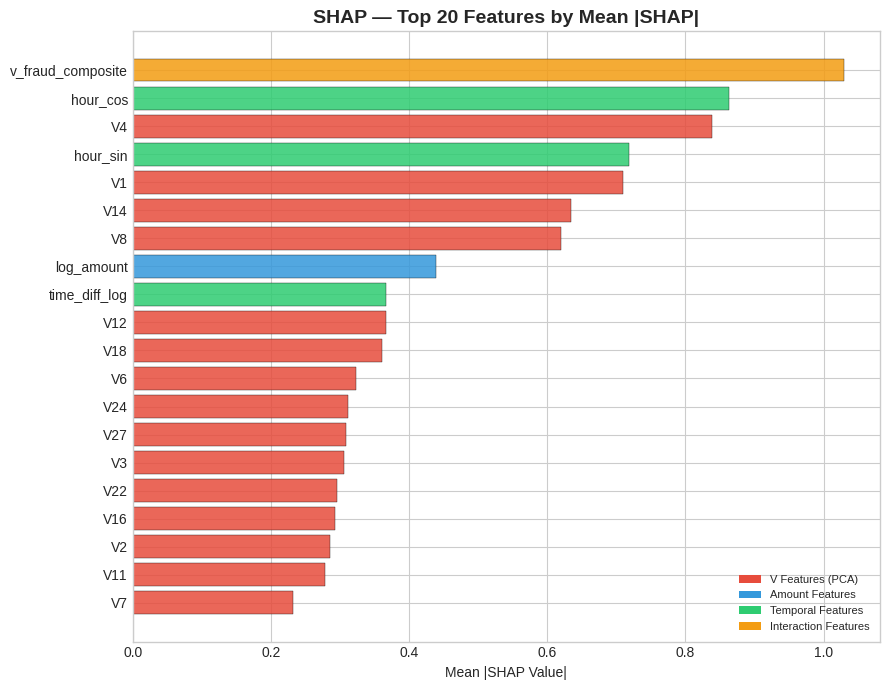

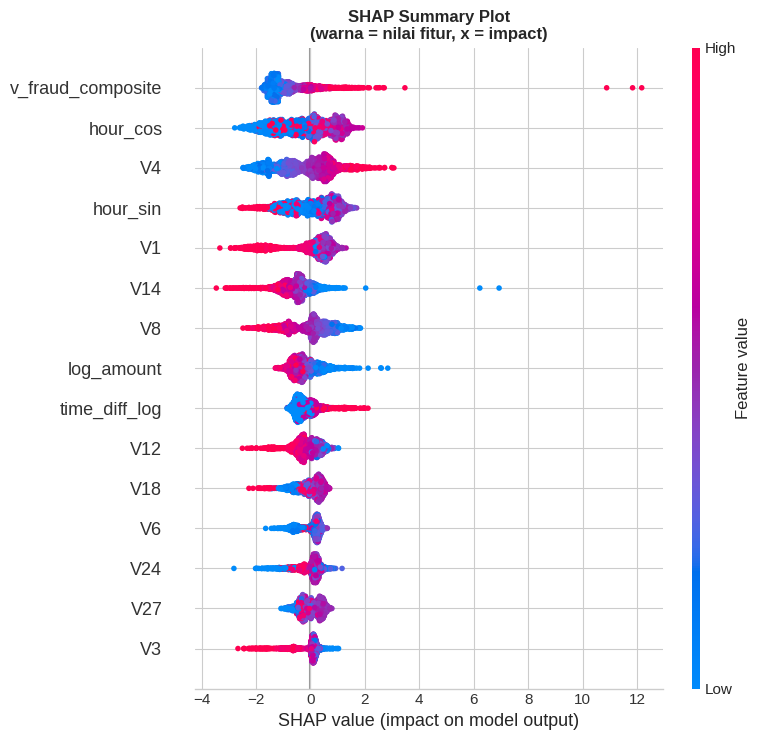

💡 INTERPRETASI GLOBAL IMPORTANCE

Top 5 fitur paling berpengaruh:
  1. v_fraud_composite         (Interaction Feature) → 1.0301
  2. hour_cos                  (Temporal Feature) → 0.8634
  3. V4                        (PCA Component) → 0.8385
  4. hour_sin                  (Temporal Feature) → 0.7182
  5. V1                        (PCA Component) → 0.7093

→ Fitur V (PCA) mendominasi karena mengandung
  informasi transaksi asli yang di-anonymize bank.
→ Fitur engineered (Amount, Temporal) melengkapi
  dengan konteks yang bisa diinterpretasi bisnis.


In [31]:
# ============================================================
# Global Feature Importance — Fitur apa yang paling penting?
# ============================================================

if isinstance(shap_values, list):
    shap_fraud = shap_values[1]
else:
    shap_fraud = shap_values

mean_shap = pd.Series(
    np.abs(shap_fraud).mean(axis=0),
    index=ALL_FEATURES
).sort_values(ascending=False)

# --- Plot 1: Bar chart top 20 ---
fig, ax = plt.subplots(figsize=(9, 7))
ax.set_title('SHAP — Top 20 Features by Mean |SHAP|',
             fontsize=14, fontweight='bold')

top_20 = mean_shap.head(20)
colors = ['#e74c3c' if f.startswith('V') else
          '#3498db' if f in AMOUNT_FEATURES else
          '#2ecc71' if f in TEMPORAL_FEATURES else
          '#f39c12'
          for f in top_20.index]

ax.barh(top_20.index[::-1], top_20.values[::-1],
        color=colors[::-1], alpha=0.85,
        edgecolor='black', linewidth=0.3)
ax.set_xlabel('Mean |SHAP Value|')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='V Features (PCA)'),
    Patch(facecolor='#3498db', label='Amount Features'),
    Patch(facecolor='#2ecc71', label='Temporal Features'),
    Patch(facecolor='#f39c12', label='Interaction Features')
]
ax.legend(handles=legend_elements, fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('shap_bar_custom.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 2: SHAP Summary Dot Plot — figure terpisah ---
shap.summary_plot(
    shap_fraud, X_test_sample,
    feature_names=ALL_FEATURES,
    max_display=15,
    show=False,
    plot_type='dot'
)
plt.title('SHAP Summary Plot\n(warna = nilai fitur, x = impact)',
          fontweight='bold')
plt.tight_layout()
plt.savefig('shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 55)
print("💡 INTERPRETASI GLOBAL IMPORTANCE")
print("=" * 55)
print(f"\nTop 5 fitur paling berpengaruh:")
for i, (feat, val) in enumerate(mean_shap.head(5).items(), 1):
    feat_type = ('PCA Component' if feat.startswith('V') else
                 'Amount Feature' if feat in AMOUNT_FEATURES else
                 'Temporal Feature' if feat in TEMPORAL_FEATURES else
                 'Interaction Feature')
    print(f"  {i}. {feat:<25} ({feat_type}) → {val:.4f}")

print(f"\n→ Fitur V (PCA) mendominasi karena mengandung")
print(f"  informasi transaksi asli yang di-anonymize bank.")
print(f"→ Fitur engineered (Amount, Temporal) melengkapi")
print(f"  dengan konteks yang bisa diinterpretasi bisnis.")

### 5.3 SHAP Summary Plot Terpisah

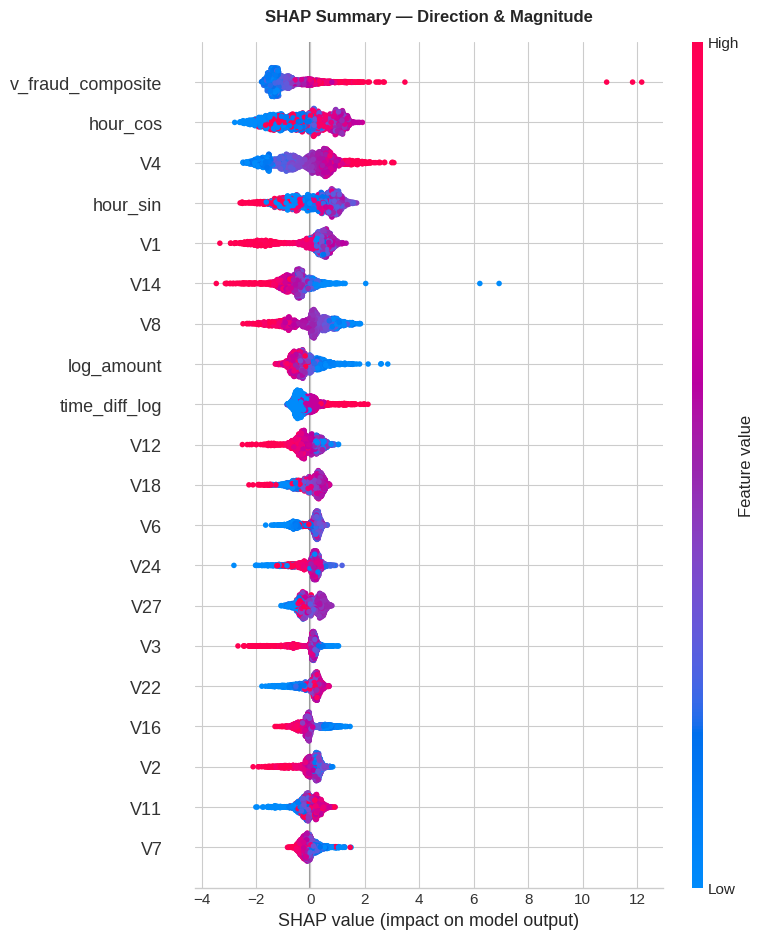

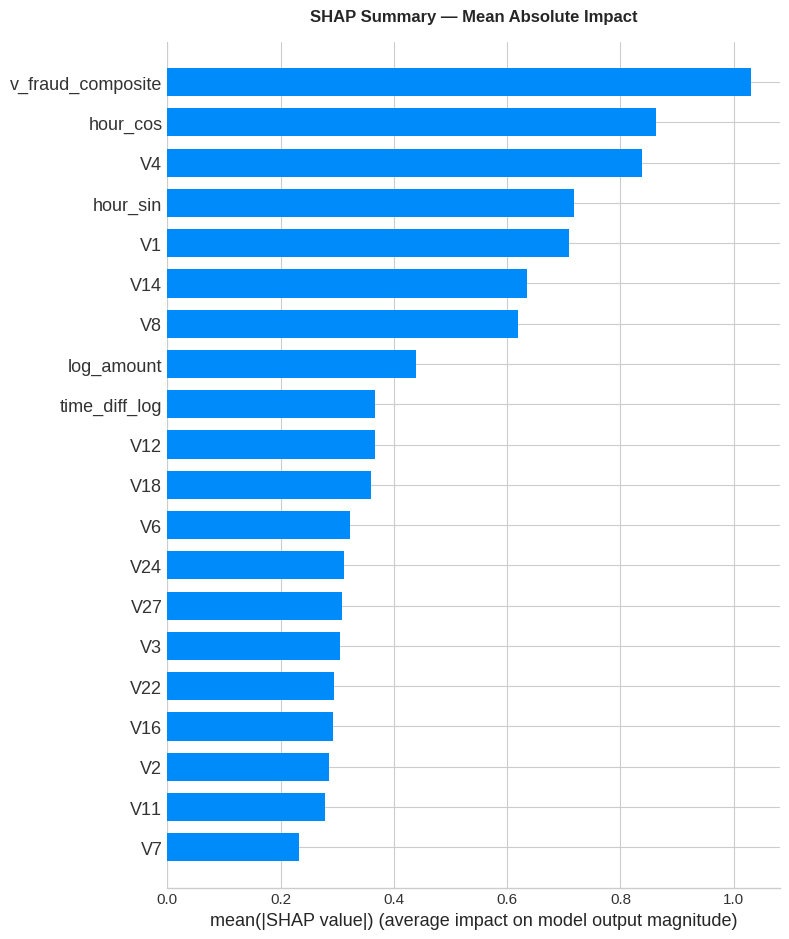


💡 CARA MEMBACA SHAP SUMMARY PLOT:

   Sumbu X  : SHAP value (positif = mendorong ke FRAUD)
   Warna    : Merah = nilai fitur tinggi, Biru = nilai fitur rendah
   Titik    : Satu titik = satu transaksi

   Contoh interpretasi:
   → V14 merah di kiri  : nilai V14 tinggi = cenderung NORMAL
   → V14 biru di kanan  : nilai V14 rendah = cenderung FRAUD
   → Ini artinya: semakin rendah V14, semakin dicurigai fraud



In [32]:
# ============================================================
# SHAP Summary Plot — Full & Clean
# ============================================================

# Plot 1: Dot summary (menunjukkan arah pengaruh)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_fraud,
    X_test_sample,
    feature_names=ALL_FEATURES,
    max_display=20,
    show=False
)
plt.title('SHAP Summary — Direction & Magnitude', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_summary_dot.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Bar summary (mean absolute, lebih mudah dibaca)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_fraud,
    X_test_sample,
    feature_names=ALL_FEATURES,
    max_display=20,
    plot_type='bar',
    show=False
)
plt.title('SHAP Summary — Mean Absolute Impact', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
💡 CARA MEMBACA SHAP SUMMARY PLOT:

   Sumbu X  : SHAP value (positif = mendorong ke FRAUD)
   Warna    : Merah = nilai fitur tinggi, Biru = nilai fitur rendah
   Titik    : Satu titik = satu transaksi

   Contoh interpretasi:
   → V14 merah di kiri  : nilai V14 tinggi = cenderung NORMAL
   → V14 biru di kanan  : nilai V14 rendah = cenderung FRAUD
   → Ini artinya: semakin rendah V14, semakin dicurigai fraud
""")

### 5.4 Individual Transaction Explanation

INDIVIDUAL TRANSACTION EXPLANATION
Ini yang paling powerful untuk portofolio:
Bisa menjelaskan MENGAPA satu transaksi spesifik dicurigai fraud

Transaksi yang dianalisis:
  → Index fraud    : 1146 (prob fraud: 1.0000)
  → Index normal   : 0 (prob fraud: 0.0000)


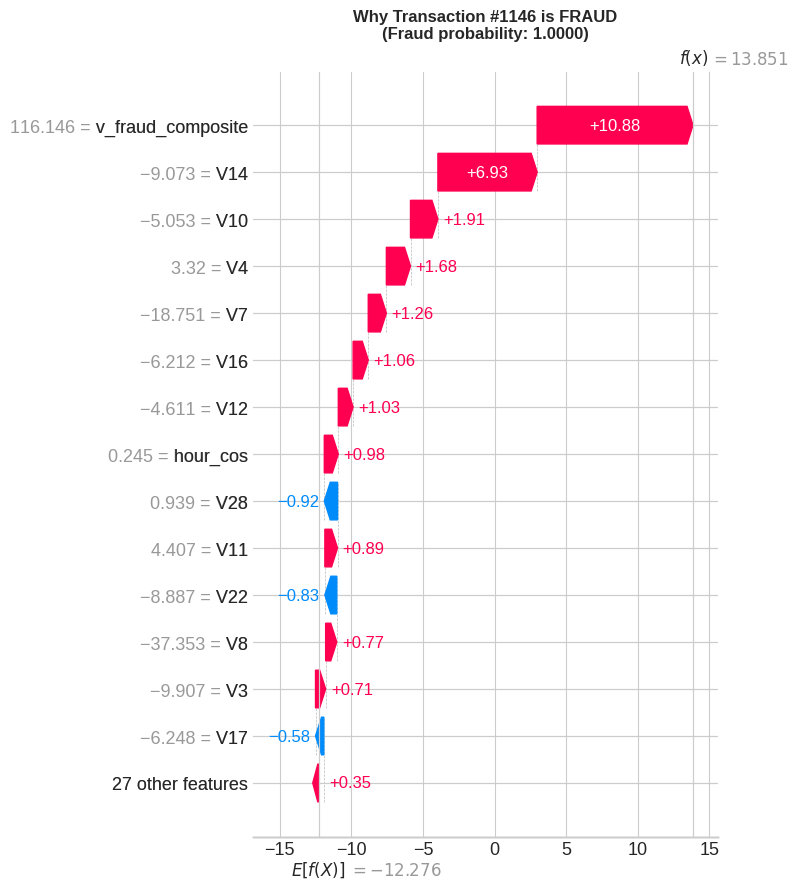

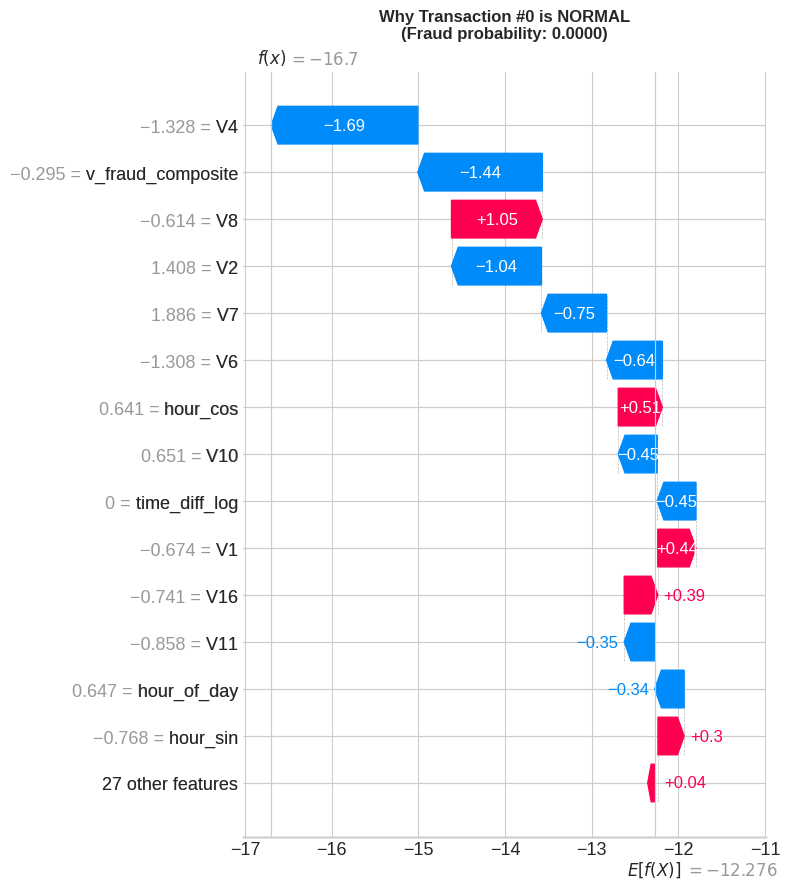


💡 CARA MEMBACA WATERFALL PLOT:

   E[f(x)] : Base value — rata-rata prediksi model secara keseluruhan
   f(x)    : Prediksi akhir untuk transaksi ini

   Bar merah  : Fitur ini MENAIKKAN probabilitas fraud
   Bar biru   : Fitur ini MENURUNKAN probabilitas fraud
   Panjang bar: Seberapa besar kontribusinya



In [33]:
# ============================================================
# Explain Individual Transactions
# ============================================================

print("INDIVIDUAL TRANSACTION EXPLANATION")
print("=" * 55)
print("Ini yang paling powerful untuk portofolio:")
print("Bisa menjelaskan MENGAPA satu transaksi spesifik dicurigai fraud\n")

# Ambil contoh: satu transaksi fraud yang berhasil terdeteksi
fraud_indices = np.where(y_test_sample.values == 1)[0]
normal_indices = np.where(y_test_sample.values == 0)[0]

# Ambil transaksi fraud pertama yang berhasil dideteksi
y_prob_sample = best_model_final.predict_proba(X_test_sample)[:, 1]
detected_fraud_idx = fraud_indices[
    np.argmax(y_prob_sample[fraud_indices])
]
normal_idx = normal_indices[0]

print(f"Transaksi yang dianalisis:")
print(f"  → Index fraud    : {detected_fraud_idx} "
      f"(prob fraud: {y_prob_sample[detected_fraud_idx]:.4f})")
print(f"  → Index normal   : {normal_idx} "
      f"(prob fraud: {y_prob_sample[normal_idx]:.4f})")

# Waterfall plot untuk transaksi fraud
plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values      = shap_fraud[detected_fraud_idx],
        base_values = explainer.expected_value[1] if isinstance(
                        explainer.expected_value, list)
                      else explainer.expected_value,
        data        = X_test_sample.iloc[detected_fraud_idx].values,
        feature_names = ALL_FEATURES
    ),
    max_display=15,
    show=False
)
plt.title(f'Why Transaction #{detected_fraud_idx} is FRAUD\n'
          f'(Fraud probability: {y_prob_sample[detected_fraud_idx]:.4f})',
          fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

# Waterfall plot untuk transaksi normal
plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values      = shap_fraud[normal_idx],
        base_values = explainer.expected_value[1] if isinstance(
                        explainer.expected_value, list)
                      else explainer.expected_value,
        data        = X_test_sample.iloc[normal_idx].values,
        feature_names = ALL_FEATURES
    ),
    max_display=15,
    show=False
)
plt.title(f'Why Transaction #{normal_idx} is NORMAL\n'
          f'(Fraud probability: {y_prob_sample[normal_idx]:.4f})',
          fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_normal.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
💡 CARA MEMBACA WATERFALL PLOT:

   E[f(x)] : Base value — rata-rata prediksi model secara keseluruhan
   f(x)    : Prediksi akhir untuk transaksi ini

   Bar merah  : Fitur ini MENAIKKAN probabilitas fraud
   Bar biru   : Fitur ini MENURUNKAN probabilitas fraud
   Panjang bar: Seberapa besar kontribusinya
""")

### 5.5 SHAP Dependence Plot

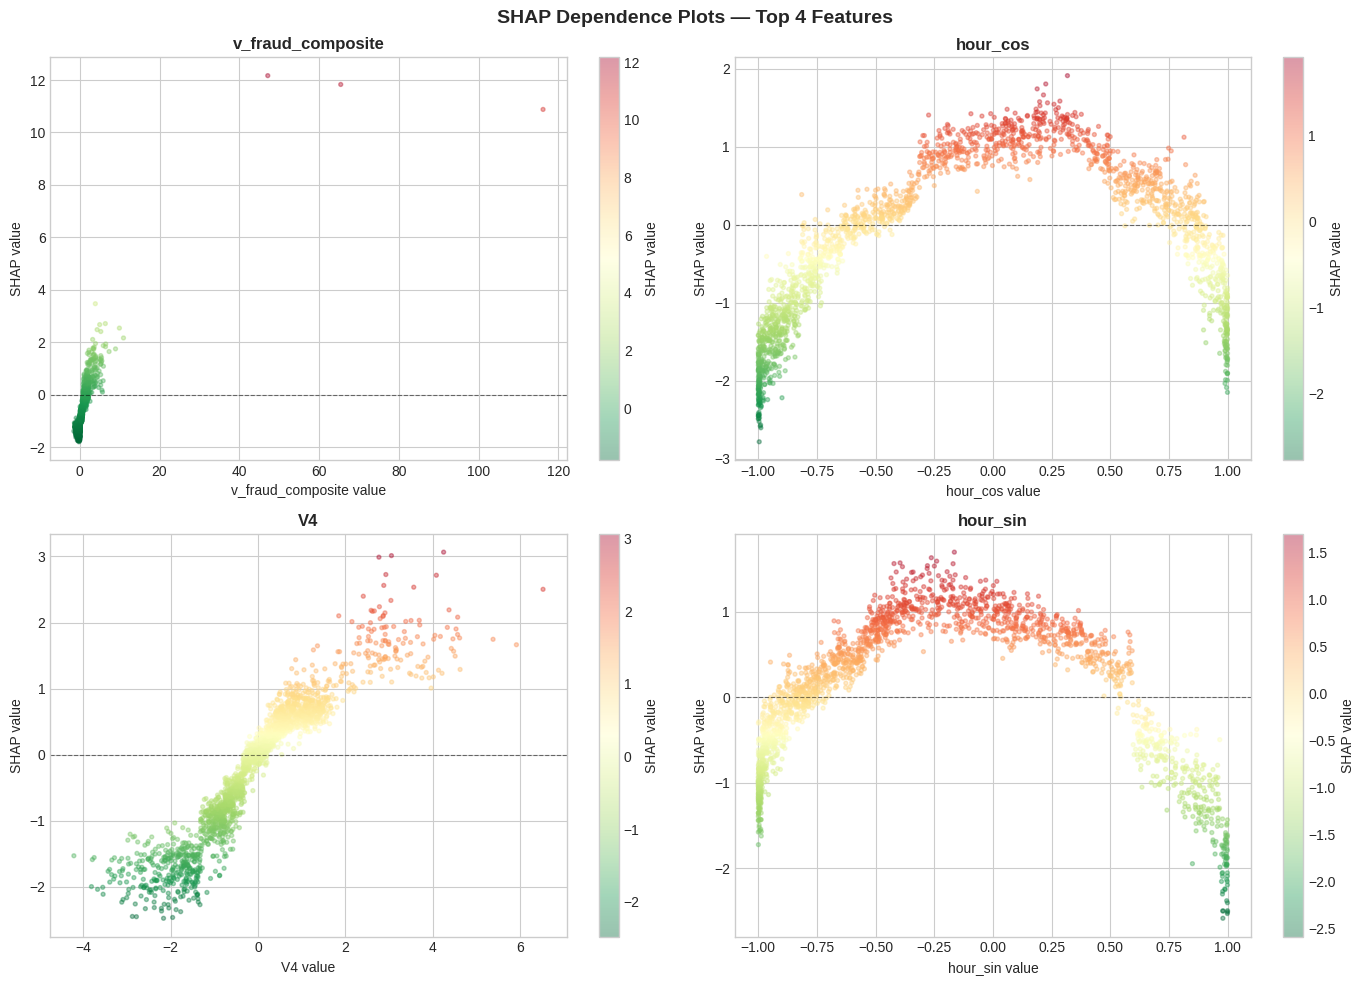


💡 CARA MEMBACA DEPENDENCE PLOT:

   Sumbu X  : Nilai aktual fitur tersebut
   Sumbu Y  : SHAP value (kontribusi ke prediksi fraud)

   Titik di atas garis putus-putus = mendorong ke fraud
   Titik di bawah garis putus-putus = mendorong ke normal

   Plot ini menunjukkan hubungan NON-LINEAR antara
   nilai fitur dan pengaruhnya — sesuatu yang tidak bisa
   ditangkap oleh simple correlation.



In [34]:
# ============================================================
# SHAP Dependence Plot — Hubungan non-linear fitur vs impact
# ============================================================

# Ambil top 4 fitur berdasarkan mean SHAP
top_4_features = mean_shap.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SHAP Dependence Plots — Top 4 Features',
             fontsize=14, fontweight='bold')

for ax, feat in zip(axes.flatten(), top_4_features):
    feat_idx = ALL_FEATURES.index(feat)

    # Scatter: nilai fitur vs SHAP value, warna = interaksi dengan fitur lain
    scatter = ax.scatter(
        X_test_sample[feat],
        shap_fraud[:, feat_idx],
        c=shap_fraud[:, feat_idx],
        cmap='RdYlGn_r',
        alpha=0.4,
        s=8
    )
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlabel(f'{feat} value')
    ax.set_ylabel('SHAP value')
    ax.set_title(f'{feat}', fontweight='bold')
    plt.colorbar(scatter, ax=ax, label='SHAP value')

plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
💡 CARA MEMBACA DEPENDENCE PLOT:

   Sumbu X  : Nilai aktual fitur tersebut
   Sumbu Y  : SHAP value (kontribusi ke prediksi fraud)

   Titik di atas garis putus-putus = mendorong ke fraud
   Titik di bawah garis putus-putus = mendorong ke normal

   Plot ini menunjukkan hubungan NON-LINEAR antara
   nilai fitur dan pengaruhnya — sesuatu yang tidak bisa
   ditangkap oleh simple correlation.
""")

### 5.6 Business Impact Simulation


BUSINESS IMPACT SIMULATION
Mengubah angka model menjadi bahasa bisnis.
Ini yang akan recruiter ingat setelah interview selesai.

Asumsi:
  - Rata-rata kerugian per fraud       : €500
  - Rata-rata biaya false alarm        : €15
    (biaya operasional review manual +
     customer experience cost)
  - Dataset mewakili 2 hari transaksi
  - Scale ke 1 tahun (x 182.5)

HASIL SIMULASI — Per Test Period (2 hari)
  Fraud berhasil dicegah     :     83 kasus  → €    41,500 diselamatkan
  False alarm (biaya review) :      6 kasus  → €        90 biaya tambahan
  Fraud lolos (tidak terdeteksi):  15 kasus  → €     7,500 kerugian
  ──────────────────────────────────────────────────
  Net benefit (2 hari)       :            €    41,410

PROYEKSI TAHUNAN
  Tanpa sistem deteksi  → Kerugian : €   8,942,500/tahun
  Dengan sistem deteksi → Net benefit: €   7,557,325/tahun
  Penghematan total     :             €   8,926,075/tahun
  Fraud recall rate     :             84.7% fraud tertangkap


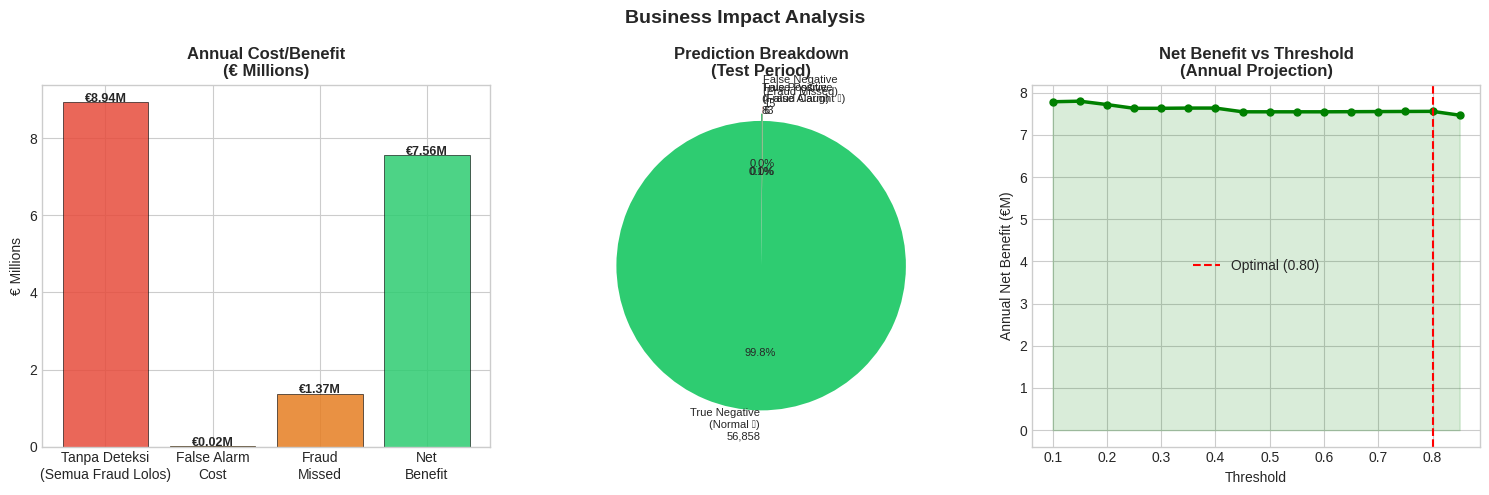

In [35]:
# ============================================================
# Business Impact Simulation
# ============================================================

print("""
BUSINESS IMPACT SIMULATION
===========================
Mengubah angka model menjadi bahasa bisnis.
Ini yang akan recruiter ingat setelah interview selesai.

Asumsi:
  - Rata-rata kerugian per fraud       : €500
  - Rata-rata biaya false alarm        : €15
    (biaya operasional review manual +
     customer experience cost)
  - Dataset mewakili 2 hari transaksi
  - Scale ke 1 tahun (x 182.5)
""")

# Ambil angka dari model terbaik dengan threshold optimal
tp = metrics_final['tp']
fp = metrics_final['fp']
fn = metrics_final['fn']
tn = metrics_final['tn']

# Parameter bisnis
AVG_FRAUD_LOSS    = 500    # € per fraud tidak terdeteksi
FALSE_ALARM_COST  = 15     # € per false alarm
SCALE_TO_YEAR     = 182.5  # dataset ≈ 2 hari

# Hitung impact
fraud_prevented   = tp * AVG_FRAUD_LOSS
false_alarm_cost  = fp * FALSE_ALARM_COST
fraud_missed_cost = fn * AVG_FRAUD_LOSS
net_benefit       = fraud_prevented - false_alarm_cost

# Scale ke tahunan
annual_prevented  = fraud_prevented * SCALE_TO_YEAR
annual_fa_cost    = false_alarm_cost * SCALE_TO_YEAR
annual_missed     = fraud_missed_cost * SCALE_TO_YEAR
annual_net        = net_benefit * SCALE_TO_YEAR

# Bandingkan: dengan model vs tanpa model (semua fraud lolos)
no_model_loss     = (tp + fn) * AVG_FRAUD_LOSS  # semua fraud lolos
annual_no_model   = no_model_loss * SCALE_TO_YEAR

print("=" * 60)
print("HASIL SIMULASI — Per Test Period (2 hari)")
print("=" * 60)
print(f"  Fraud berhasil dicegah     : {tp:>6,} kasus  "
      f"→ €{fraud_prevented:>10,.0f} diselamatkan")
print(f"  False alarm (biaya review) : {fp:>6,} kasus  "
      f"→ €{false_alarm_cost:>10,.0f} biaya tambahan")
print(f"  Fraud lolos (tidak terdeteksi): {fn:>3,} kasus  "
      f"→ €{fraud_missed_cost:>10,.0f} kerugian")
print(f"  {'─'*50}")
print(f"  Net benefit (2 hari)       :          "
      f"  €{net_benefit:>10,.0f}")

print(f"\n{'='*60}")
print(f"PROYEKSI TAHUNAN")
print(f"{'='*60}")
print(f"  Tanpa sistem deteksi  → Kerugian : €{annual_no_model:>12,.0f}/tahun")
print(f"  Dengan sistem deteksi → Net benefit: €{annual_net:>12,.0f}/tahun")
print(f"  Penghematan total     :             €{annual_no_model - annual_fa_cost:>12,.0f}/tahun")
print(f"  Fraud recall rate     :             "
      f"{tp/(tp+fn)*100:.1f}% fraud tertangkap")

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Business Impact Analysis', fontsize=14, fontweight='bold')

# Plot 1: Cost comparison
categories   = ['Tanpa Deteksi\n(Semua Fraud Lolos)',
                'False Alarm\nCost', 'Fraud\nMissed', 'Net\nBenefit']
values       = [annual_no_model/1e6, annual_fa_cost/1e6,
                annual_missed/1e6, annual_net/1e6]
bar_colors   = ['#e74c3c', '#f39c12', '#e67e22', '#2ecc71']

bars = axes[0].bar(categories, values, color=bar_colors,
                   alpha=0.85, edgecolor='black', linewidth=0.5)
axes[0].set_title('Annual Cost/Benefit\n(€ Millions)', fontweight='bold')
axes[0].set_ylabel('€ Millions')
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'€{val:.2f}M', ha='center', fontsize=9, fontweight='bold')

# Plot 2: Confusion breakdown
labels   = [f'True Negative\n(Normal ✓)\n{tn:,}',
            f'False Positive\n(False Alarm)\n{fp:,}',
            f'False Negative\n(Fraud Missed)\n{fn:,}',
            f'True Positive\n(Fraud Caught ✓)\n{tp:,}']
sizes    = [tn, fp, fn, tp]
colors_p = ['#2ecc71', '#f39c12', '#e74c3c', '#27ae60']
explode  = (0, 0.05, 0.1, 0.05)

axes[1].pie(sizes, labels=labels, colors=colors_p,
            explode=explode, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 8})
axes[1].set_title('Prediction Breakdown\n(Test Period)',
                  fontweight='bold')

# Plot 3: Threshold sensitivity — bagaimana net benefit berubah per threshold
net_benefits = []
for _, row in thresh_df.iterrows():
    nb = (row['tp'] * AVG_FRAUD_LOSS) - (row['fp'] * FALSE_ALARM_COST)
    net_benefits.append(nb * SCALE_TO_YEAR / 1e6)

axes[2].plot(thresh_df['threshold'], net_benefits,
             'g-o', linewidth=2.5, markersize=5)
axes[2].axvline(x=optimal_threshold, color='red', linestyle='--',
                label=f'Optimal ({optimal_threshold:.2f})')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('Annual Net Benefit (€M)')
axes[2].set_title('Net Benefit vs Threshold\n(Annual Projection)',
                  fontweight='bold')
axes[2].legend()
axes[2].fill_between(thresh_df['threshold'], net_benefits,
                     alpha=0.15, color='green')

plt.tight_layout()
plt.savefig('business_impact.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.7 Fase 5 Summary

In [36]:
# ============================================================
# Fase 5 Summary
# ============================================================

print("=" * 55)
print("           FASE 5 SUMMARY")
print("=" * 55)
print(f"""
  EXPLAINABILITY:
  ✅ SHAP TreeExplainer pada {sample_size} test samples
  ✅ Global importance — top fitur berdasarkan mean |SHAP|
  ✅ Summary plot — arah & magnitude pengaruh tiap fitur
  ✅ Waterfall plot — penjelasan per transaksi individual
  ✅ Dependence plot — hubungan non-linear fitur vs impact

  BUSINESS IMPACT (Proyeksi Tahunan):
  ✅ Fraud dicegah     : €{annual_prevented / 1e3:.0f}K+/tahun
  ✅ Net benefit       : €{annual_net/1e6:.2f}M/tahun
  ✅ Recall rate       : {tp/(tp+fn)*100:.1f}% fraud tertangkap
  ✅ Threshold optimal : {optimal_threshold:.2f} (business-aware tuning)

  ARTIFACTS TERSIMPAN:
  → shap_global_importance.png
  → shap_summary_dot.png
  → shap_summary_bar.png
  → shap_waterfall_fraud.png
  → shap_waterfall_normal.png
  → shap_dependence.png
  → business_impact.png
""")
print("=" * 55)

           FASE 5 SUMMARY

  EXPLAINABILITY:
  ✅ SHAP TreeExplainer pada 2000 test samples
  ✅ Global importance — top fitur berdasarkan mean |SHAP|
  ✅ Summary plot — arah & magnitude pengaruh tiap fitur
  ✅ Waterfall plot — penjelasan per transaksi individual
  ✅ Dependence plot — hubungan non-linear fitur vs impact

  BUSINESS IMPACT (Proyeksi Tahunan):
  ✅ Fraud dicegah     : €7574K+/tahun
  ✅ Net benefit       : €7.56M/tahun
  ✅ Recall rate       : 84.7% fraud tertangkap
  ✅ Threshold optimal : 0.80 (business-aware tuning)

  ARTIFACTS TERSIMPAN:
  → shap_global_importance.png
  → shap_summary_dot.png
  → shap_summary_bar.png
  → shap_waterfall_fraud.png
  → shap_waterfall_normal.png
  → shap_dependence.png
  → business_impact.png

